<a href="https://colab.research.google.com/github/nguyen1212/ai-learning/blob/main/Module_3_2_Vector_Databases_and_Indexing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 3.2: Similarity Metrics, Indexing Algorithms & Vector Databases

## Learning Objectives

By the end of this module, you will be able to:
- Explain what an **embedding vector** is and trace the full Tokenize → Encode → Pool pipeline
- Describe how embeddings are **stored in a vector database** and visualise the vector space as a searchable map
- Understand and compare **Cosine**, **Euclidean**, and **Dot Product** similarity — including when they disagree
- Explain why brute-force KNN fails at scale and what ANN solves
- Implement and benchmark four indexing algorithms: **Flat**, **IVF**, **HNSW**, **IVF-PQ**
- Read tradeoff charts: build time, query latency, recall@k, and memory footprint
- Understand how indexing choices impact **latency**, **recall**, and **memory** across different scales
- Compare **ChromaDB**, **FAISS**, and **Qdrant** by API and use case

---

## Module Overview

| Section | Topic |
|---------|-------|
| 0 | What Is an Embedding Vector? — generation pipeline, tokenization, pooling |
| 0d | How Embeddings Are Stored — ingestion pipeline, record structure, 2D vector space map, upsert |
| 1 | Similarity Metrics — Cosine, Euclidean, Dot Product |
| 2 | The Scale Problem — why brute-force search breaks |
| 3 | Indexing Algorithms — Flat → IVF → HNSW → IVF-PQ |
| 3.5 | Index Impact on Search Performance — Latency, Recall, Memory tradeoffs |
| 4 | Vector Database Comparison — ChromaDB, FAISS, Qdrant |

> **Dependency on Module 3.1:** This module is standalone. We use synthetic data so no PDF or API key is required for Sections 0–3.5. Section 4 (vector DBs) needs ChromaDB and Qdrant only.

In [ ]:
!pip install chromadb qdrant-client faiss-cpu sentence-transformers scikit-learn pymupdf openai numpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.4/390.4 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.9/24.9 MB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/

In [ ]:
import time
import os
import tempfile
import numpy as np
import matplotlib.pyplot as plt
import faiss
import chromadb
from qdrant_client import QdrantClient
from qdrant_client.models import Distance, VectorParams, PointStruct
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModel
import torch

np.random.seed(42)

# Local embedding model — used for Section 1 and Section 4
# Downloads ~90MB on first run, cached afterwards
embed_model = SentenceTransformer('all-MiniLM-L6-v2')
MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
hf_model   = AutoModel.from_pretrained(MODEL_NAME)
hf_model.eval()

print(f'FAISS version:    {faiss.__version__}')
print(f'Embedding model:  all-MiniLM-L6-v2  (384 dims, local, no API key needed)')
print('All dependencies loaded.')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FAISS version:    1.13.2
Embedding model:  all-MiniLM-L6-v2  (384 dims, local, no API key needed)
All dependencies loaded.


---
## Section 0: What Is an Embedding Vector?

Before we compare similarity metrics or benchmark indexes, we need to understand the fundamental object we are working with: the **embedding vector**.

### The Core Idea

An embedding vector is a **dense list of floating-point numbers** that encodes the *meaning* of some input (text, image, audio) in a way that a computer can reason about mathematically.

```
"The MFV meet-up celebrates employees."
              │
              ▼
    ┌─────────────────────┐
    │   Embedding Model   │  ← Transformer (e.g. all-MiniLM-L6-v2)
    └─────────────────────┘
              │
              ▼
  [ 0.032, -0.118,  0.274,  0.051, -0.203, ... ]  ← 384 numbers
```

The key property: **semantically similar inputs produce vectors that are close together** in the high-dimensional space. This is what makes semantic search possible — instead of matching keywords, we measure geometric closeness between vectors.

### How the Model Generates an Embedding (3 Steps)

```
Step 1 — Tokenize
  Text  →  ["The", "MF", "##V", "meet", "-", "up", "celebrate", "##s", ...]
  Tokens → Integer IDs   [101, 1996, 13699, ...]

Step 2 — Encode (Transformer)
  Each token ID → 384-dim context-aware vector
  (attention layers let each token "look at" all others)

Step 3 — Pool
  All token vectors → one single 384-dim vector (mean pooling)
  This is the sentence embedding.
```

> **Why 384 dimensions?** This is a model design choice. Larger models use 768, 1536, or 3072 dims. More dimensions can capture richer meaning but cost more memory and compute. `all-MiniLM-L6-v2` uses 384 as a speed/quality balance.

Input sentence : "The MFV Thank-you meet-up celebrates employee contributions."

Output type    : <class 'numpy.ndarray'>
Output shape   : (384,)    ← 384 numbers in a 1-D array
Data type      : float32  ← 32-bit float

First 10 values: [-0.0494999997317791, 0.04430000111460686, 0.016200000420212746, -0.045099999755620956, 0.04780000075697899, 0.09040000289678574, 0.06069999933242798, -0.04450000077486038, 0.020899999886751175, -0.01899999938905239]
Last  10 values: [-0.03220000118017197, -0.018200000748038292, 0.039000000804662704, 0.023099999874830246, 0.1428000032901764, -0.09809999912977219, 0.05389999970793724, -0.026599999517202377, 0.0674000009894371, -0.09049999713897705]

Statistics:
  Min   : -0.1676
  Max   : 0.1463
  Mean  : 0.0012
  Std   : 0.0510
  L2 norm (magnitude): 1.0000  ← ≈1.0 because model normalizes output



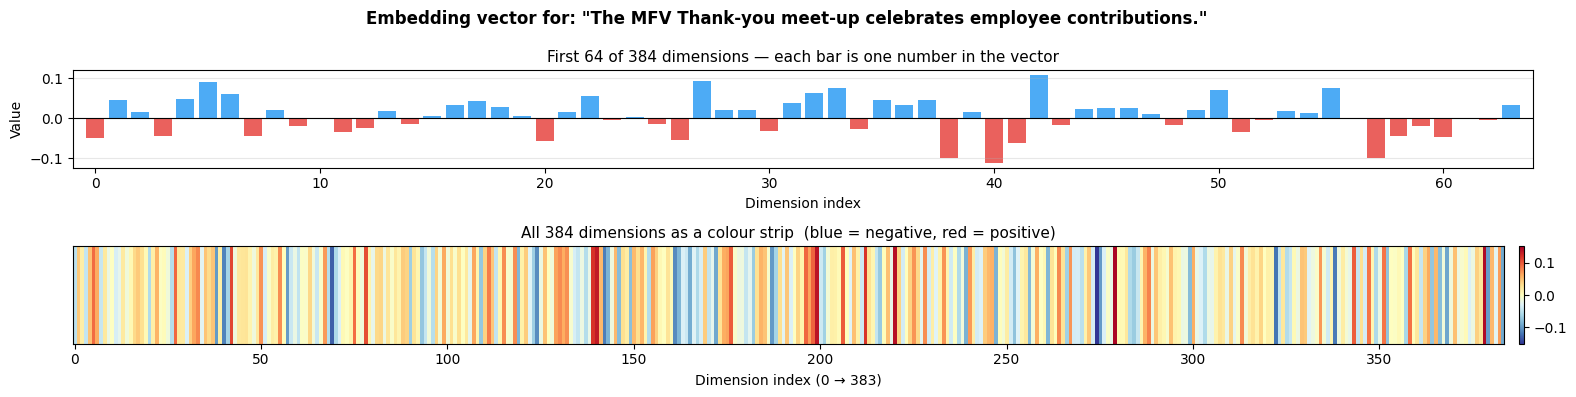

In [ ]:
# =============================================================
# Section 0a: Inspecting a Single Embedding Vector
# =============================================================
# Let's embed one sentence and examine the raw vector in detail.
# =============================================================

sentence = "The MFV Thank-you meet-up celebrates employee contributions."

# Generate the embedding — returns a numpy array of shape (384,)
vector = embed_model.encode(sentence)

print(f'Input sentence : "{sentence}"')
print()
print(f'Output type    : {type(vector)}')
print(f'Output shape   : {vector.shape}    ← 384 numbers in a 1-D array')
print(f'Data type      : {vector.dtype}  ← 32-bit float')
print()
print(f'First 10 values: {vector[:10].round(4).tolist()}')
print(f'Last  10 values: {vector[-10:].round(4).tolist()}')
print()
print(f'Statistics:')
print(f'  Min   : {vector.min():.4f}')
print(f'  Max   : {vector.max():.4f}')
print(f'  Mean  : {vector.mean():.4f}')
print(f'  Std   : {vector.std():.4f}')
print(f'  L2 norm (magnitude): {np.linalg.norm(vector):.4f}  ← ≈1.0 because model normalizes output')
print()

# Visualize the full 384-dim vector as a heatmap
fig, axes = plt.subplots(2, 1, figsize=(16, 4))

# Top: raw values as a 1-D bar chart (first 64 dims for clarity)
axes[0].bar(range(64), vector[:64], color=np.where(vector[:64] >= 0, '#2196F3', '#E53935'), alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlim(-1, 64)
axes[0].set_title(f'First 64 of 384 dimensions — each bar is one number in the vector', fontsize=11)
axes[0].set_xlabel('Dimension index')
axes[0].set_ylabel('Value')
axes[0].grid(axis='y', alpha=0.3)

# Bottom: full 384-dim vector as a colour strip (heatmap)
axes[1].imshow(vector.reshape(1, -1), aspect='auto', cmap='RdYlBu_r', vmin=-0.15, vmax=0.15)
axes[1].set_yticks([])
axes[1].set_title('All 384 dimensions as a colour strip  (blue = negative, red = positive)', fontsize=11)
axes[1].set_xlabel('Dimension index (0 → 383)')
plt.colorbar(axes[1].images[0], ax=axes[1], orientation='vertical', fraction=0.01, pad=0.01)

plt.suptitle(f'Embedding vector for: "{sentence}"', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

STEP 1 — TOKENIZE
Input  : "The MFV meet-up celebrates employee contributions."

Token words : ['[CLS]', 'the', 'm', '##f', '##v', 'meet', '-', 'up', 'celebrates', 'employee', 'contributions', '.', '[SEP]']
Token IDs   : [101, 1996, 1049, 2546, 2615, 3113, 1011, 2039, 21566, 7904, 5857, 1012, 102]
Sequence length: 13 tokens

Notes:
  [CLS] = special "start" token;  [SEP] = special "end" token
  "contributions" → ["contribution", "##s"]  (WordPiece sub-word splitting)

STEP 2 — ENCODE (Transformer forward pass)
Transformer output shape: (1, 13, 384)
  = (batch=1, seq_len=13, hidden_dim=384)

Each of the 13 tokens now has its own 384-dim context-aware vector.
Example — first 8 dims of each token:

  Token              dim00  dim01  dim02  dim03  dim04  dim05  dim06  dim07
  ------------------ ------  ------  ------  ------  ------  ------  ------  ------
  [CLS]              -0.112   0.004  -0.332  -0.235  -0.029   0.263   0.081  -0.464
  the                -0.123  -0.104  -0.276   0.145

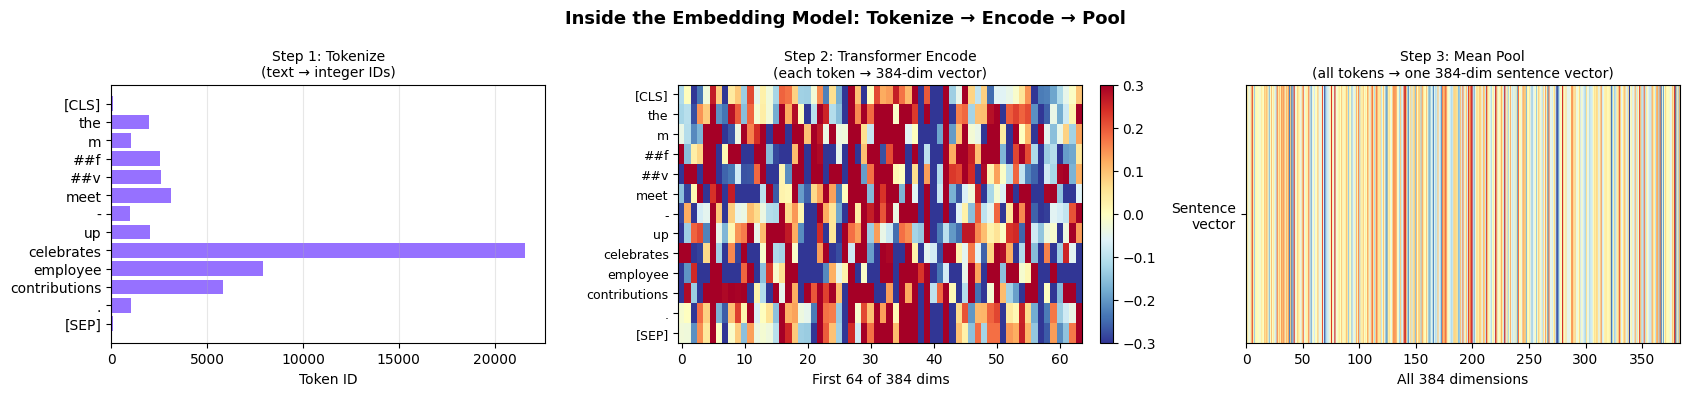

In [ ]:
# =============================================================
# Section 0c: Under the Hood — Tokenization → Encode → Pool
# =============================================================
# We expose each intermediate step so you can see exactly what
# the embedding model does internally to produce the final vector.
# =============================================================

demo_sentence = "The MFV meet-up celebrates employee contributions."

# ------ STEP 1: Tokenize ------
tokens = tokenizer(demo_sentence, return_tensors='pt', padding=True, truncation=True)
token_ids   = tokens['input_ids'][0].tolist()
token_words = tokenizer.convert_ids_to_tokens(token_ids)

print('=' * 65)
print('STEP 1 — TOKENIZE')
print('=' * 65)
print(f'Input  : "{demo_sentence}"')
print()
print(f'Token words : {token_words}')
print(f'Token IDs   : {token_ids}')
print(f'Sequence length: {len(token_ids)} tokens')
print()
print('Notes:')
print('  [CLS] = special "start" token;  [SEP] = special "end" token')
print('  "contributions" → ["contribution", "##s"]  (WordPiece sub-word splitting)')

# ------ STEP 2: Encode (Transformer) ------
print()
print('=' * 65)
print('STEP 2 — ENCODE (Transformer forward pass)')
print('=' * 65)

with torch.no_grad():
    outputs = hf_model(**tokens)

token_embeddings = outputs.last_hidden_state  # shape: (1, seq_len, 384)
print(f'Transformer output shape: {tuple(token_embeddings.shape)}')
print(f'  = (batch=1, seq_len={token_embeddings.shape[1]}, hidden_dim={token_embeddings.shape[2]})')
print()
print('Each of the', token_embeddings.shape[1], 'tokens now has its own 384-dim context-aware vector.')
print('Example — first 8 dims of each token:')
print()
print(f'  {"Token":<18}', '  '.join([f'dim{i:02d}' for i in range(8)]))
print(f'  {"-"*18}', '  '.join(['------'] * 8))
for i, (word, tok_vec) in enumerate(zip(token_words, token_embeddings[0])):
    vals = tok_vec[:8].numpy().round(3)
    print(f'  {word:<18}', '  '.join([f'{v:6.3f}' for v in vals]))

# ------ STEP 3: Mean Pooling ------
print()
print('=' * 65)
print('STEP 3 — MEAN POOL → final sentence embedding')
print('=' * 65)

attention_mask   = tokens['attention_mask']
mask_expanded    = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
sum_embeddings   = torch.sum(token_embeddings * mask_expanded, dim=1)
sum_mask         = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
sentence_vec_raw = (sum_embeddings / sum_mask)[0].numpy()

# L2 normalize (sentence-transformers does this automatically)
sentence_vec = sentence_vec_raw / np.linalg.norm(sentence_vec_raw)

print('Mean pool = average all non-padding token vectors along the sequence dimension.')
print(f'Result shape: {sentence_vec.shape}   ← one 384-dim vector for the whole sentence')
print(f'L2 norm after normalization: {np.linalg.norm(sentence_vec):.6f}  (≈ 1.0)')
print()

# Verify it matches embed_model.encode()
ref_vec = embed_model.encode(demo_sentence)
match   = np.allclose(sentence_vec, ref_vec, atol=1e-4)
print(f'Matches embed_model.encode() output: {match}  ✓' if match else
      f'Matches embed_model.encode() output: {match}  (small numerical diff OK)')

# --- Visual summary of the 3-step pipeline ---
fig, axes = plt.subplots(1, 3, figsize=(17, 4))

# Panel 1: Token ID bar chart
axes[0].barh(range(len(token_ids)), token_ids, color='#7C4DFF', alpha=0.8)
axes[0].set_yticks(range(len(token_words)))
axes[0].set_yticklabels(token_words, fontsize=10)
axes[0].set_xlabel('Token ID')
axes[0].set_title('Step 1: Tokenize\n(text → integer IDs)', fontsize=10)
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Panel 2: Token-level embeddings heatmap (all tokens × first 64 dims)
tok_np = token_embeddings[0].numpy()
im2 = axes[1].imshow(tok_np[:, :64], aspect='auto', cmap='RdYlBu_r', vmin=-0.3, vmax=0.3)
axes[1].set_yticks(range(len(token_words)))
axes[1].set_yticklabels(token_words, fontsize=9)
axes[1].set_xlabel('First 64 of 384 dims')
axes[1].set_title('Step 2: Transformer Encode\n(each token → 384-dim vector)', fontsize=10)
plt.colorbar(im2, ax=axes[1], fraction=0.03, pad=0.04)

# Panel 3: Final pooled sentence vector (colour strip)
axes[2].imshow(sentence_vec.reshape(1, -1), aspect='auto', cmap='RdYlBu_r', vmin=-0.15, vmax=0.15)
axes[2].set_yticks([0])
axes[2].set_yticklabels(['Sentence\nvector'], fontsize=10)
axes[2].set_xlabel('All 384 dimensions')
axes[2].set_title('Step 3: Mean Pool\n(all tokens → one 384-dim sentence vector)', fontsize=10)

plt.suptitle('Inside the Embedding Model: Tokenize → Encode → Pool', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Section 0 Summary

| Step | Input | Output | What happens |
|------|-------|--------|--------------|
| **Tokenize** | Raw text | Integer token IDs | Text split into sub-words; mapped to vocabulary indices |
| **Encode** | Token IDs | `(seq_len, 384)` tensor | Transformer layers produce a context-aware vector **per token** |
| **Pool** | `(seq_len, 384)` tensor | `(384,)` vector | Average all token vectors → one vector for the whole sentence |
| **Normalize** | Raw pooled vector | Unit-norm `(384,)` vector | Divide by L2 norm so all vectors live on the unit hypersphere |

**Why does meaning end up in the numbers?**
The model was trained on millions of sentence pairs (e.g. NLI, semantic textual similarity datasets). The training objective forced semantically related sentences to produce similar vectors and unrelated ones to produce distant vectors. The 384 dimensions are not individually interpretable — meaning is distributed across all of them together.

**Bridge to Section 1:** Now that we have these vectors, the question is: *how do we measure how similar two of them are?* That is exactly what the three similarity metrics in Section 1 answer.

---
## Section 0d: How Embeddings Are Stored in a Vector Database

Once we have embedding vectors, we need to **store** them so we can search across them later. This is exactly what a vector database does — but what does "storing a vector" actually mean?

### A Vector DB Record vs a Traditional DB Row

```
Traditional (SQL) DB row:
  ┌──────┬──────────────────────────────────────┬─────────┐
  │  id  │  text                                │  topic  │
  ├──────┼──────────────────────────────────────┼─────────┤
  │   1  │  "The MFV event celebrates staff..." │  HR     │
  └──────┴──────────────────────────────────────┴─────────┘
  → You can only search by exact text or keyword match.

Vector DB record:
  ┌──────┬────────────────────────────────┬──────────────────────────────────────┬─────────┐
  │  id  │  vector (384 floats)           │  text (payload)                      │  topic  │
  ├──────┼────────────────────────────────┼──────────────────────────────────────┼─────────┤
  │   1  │  [0.032, -0.118, 0.274, ...]   │  "The MFV event celebrates staff..." │  HR     │
  └──────┴────────────────────────────────┴──────────────────────────────────────┴─────────┘
  → You can search by MEANING: "find records whose vector is close to this query vector."
```

### The Full Ingestion Pipeline

```
  Raw Documents
       │
       ▼  (chunking)
  Text Chunks  ──── metadata ────────────────────────────────┐
       │                                                      │
       ▼  (embedding model)                                   │
  Dense Vectors (float32 arrays)                             │
       │                                                      │
       ▼  (upsert)                                           │
  ┌─────────────────────────────────────────┐               │
  │          Vector Database                │               │
  │  ┌───────────────────────────────────┐  │               │
  │  │  Index (HNSW / IVF / Flat)        │◄─┘               │
  │  │  organizes vectors for fast search│                   │
  │  └───────────────────────────────────┘  ◄───────────────┘
  │  + Payload store (text, metadata)       │
  └─────────────────────────────────────────┘
       │
       ▼  (query time)
  Query Text → Query Vector → Nearest Neighbour Search → Top-k Records
```

In [ ]:
# =============================================================
# Section 0d-1: The Ingestion Pipeline — What Gets Stored
# =============================================================
# We simulate a real ingestion: raw topic sentences → chunk →
# embed → show the exact structure of every stored record.
# =============================================================
import json

# --- Mini corpus with 4 HR topics (3 sentences each = 12 chunks total) ---
corpus = {
    'recognition': [
        'The MFV Thank-you meet-up celebrates employee contributions each February.',
        'Employee recognition programs boost morale and reduce voluntary turnover.',
        'Our annual awards ceremony honors outstanding performers across all departments.',
    ],
    'recruitment': [
        'Talent acquisition focuses on attracting and selecting top candidates.',
        'The onboarding process helps new hires integrate quickly into their teams.',
        'Job descriptions should be clear, inclusive, and reflect actual responsibilities.',
    ],
    'development': [
        'Learning and development programs help employees grow their skills.',
        'Leadership coaching prepares high-potential employees for management roles.',
        'Succession planning ensures business continuity during key leadership transitions.',
    ],
    'wellness': [
        'Workplace wellness programs support employee mental and physical health.',
        'Flexible work arrangements improve work-life balance and productivity.',
        'Employee assistance programs provide confidential counseling services.',
    ],
}

# ---- STEP 1: Chunk (here each sentence is already one chunk) ----
print('STEP 1 — CHUNK')
print('=' * 60)
store_chunks = []
for topic, sentences in corpus.items():
    for i, sentence in enumerate(sentences):
        store_chunks.append({
            'id':       f'{topic}_{i}',
            'text':     sentence,
            'metadata': {'topic': topic, 'chunk_index': i},
        })
print(f'Total chunks ready to embed: {len(store_chunks)}')
print()
for c in store_chunks[:3]:
    print(f"  id='{c['id']}' | topic='{c['metadata']['topic']}'")
    print(f"  text='{c['text'][:70]}...'")
    print()
print(f'  ... ({len(store_chunks) - 3} more chunks)')

# ---- STEP 2: Embed ----
print('\nSTEP 2 — EMBED')
print('=' * 60)
store_texts   = [c['text'] for c in store_chunks]
store_vectors = embed_model.encode(store_texts, show_progress_bar=False)
print(f'Embedding output shape : {store_vectors.shape}')
print(f'  = ({len(store_chunks)} chunks  ×  {store_vectors.shape[1]} dims per vector)')
print(f'Memory for vectors     : {store_vectors.nbytes / 1024:.1f} KB  '
      f'({store_vectors.dtype}, {store_vectors.nbytes} bytes)')

# ---- STEP 3: Show the stored record structure ----
print('\nSTEP 3 — STORED RECORD STRUCTURE')
print('=' * 60)
print('Each record in the vector DB looks like:\n')
for i in range(2):
    c   = store_chunks[i]
    vec = store_vectors[i]
    print(f'┌─ Record {i} ──────────────────────────────────────────────┐')
    print(f'│  id      : {c["id"]!r}')
    print(f'│  vector  : [{", ".join(f"{v:.4f}" for v in vec[:6])}, ...]')
    print(f'│            shape={vec.shape}, dtype={vec.dtype}, norm={np.linalg.norm(vec):.4f}')
    print(f'│  payload : topic={c["metadata"]["topic"]!r}, chunk_index={c["metadata"]["chunk_index"]}')
    print(f'│  text    : {c["text"][:65]!r}')
    print(f'└───────────────────────────────────────────────────────────┘')
    print()

print('Key insight:')
print('  The vector DB stores BOTH the raw text (as metadata/payload) AND the')
print('  dense vector. At search time, only the vector is used for nearest-neighbour')
print('  lookup; the text is returned as the result payload for the LLM to read.')

STEP 1 — CHUNK
Total chunks ready to embed: 12

  id='recognition_0' | topic='recognition'
  text='The MFV Thank-you meet-up celebrates employee contributions each Febru...'

  id='recognition_1' | topic='recognition'
  text='Employee recognition programs boost morale and reduce voluntary turnov...'

  id='recognition_2' | topic='recognition'
  text='Our annual awards ceremony honors outstanding performers across all de...'

  ... (9 more chunks)

STEP 2 — EMBED
Embedding output shape : (12, 384)
  = (12 chunks  ×  384 dims per vector)
Memory for vectors     : 18.0 KB  (float32, 18432 bytes)

STEP 3 — STORED RECORD STRUCTURE
Each record in the vector DB looks like:

┌─ Record 0 ──────────────────────────────────────────────┐
│  id      : 'recognition_0'
│  vector  : [-0.0529, 0.0182, 0.0327, -0.0179, 0.0347, 0.0991, ...]
│            shape=(384,), dtype=float32, norm=1.0000
│  payload : topic='recognition', chunk_index=0
│  text    : 'The MFV Thank-you meet-up celebrates employee contr

/tmp/ipykernel_1299/3850145798.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


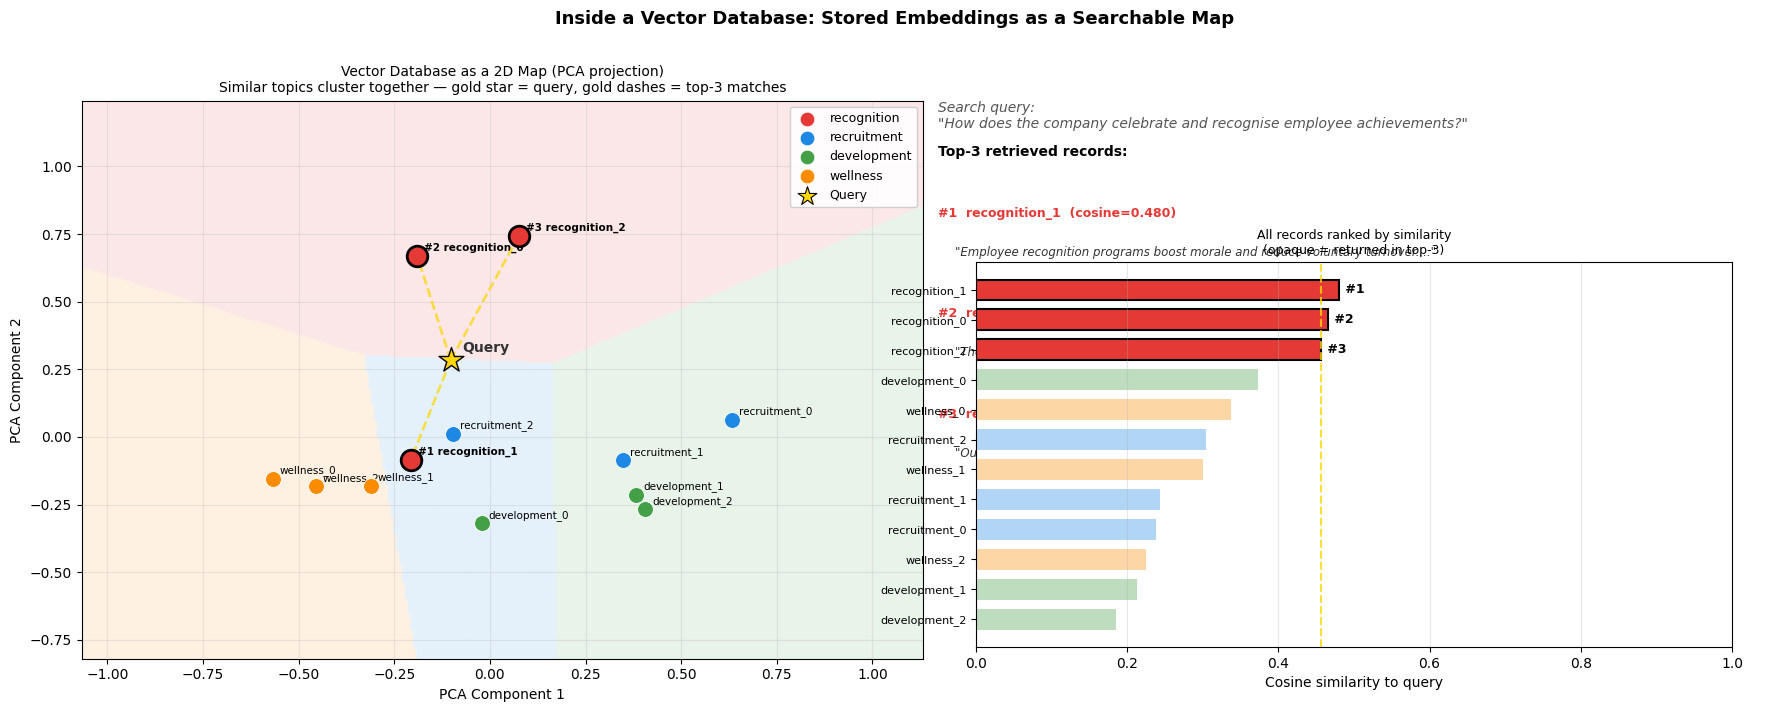

Observation:
  Records from the same topic cluster together in 2D — the model learned that
  "recognition", "awards", and "MFV meet-up" share semantic space.

  The search query lands near the recognition cluster, so all 3 top results
  come from that topic — even though none of them contain the exact query words.
  This is semantic search: meaning over keywords.


In [ ]:
# =============================================================
# Section 0d-2: Visualising the Vector Space — the DB as a Map
# =============================================================
# 384-dim space is impossible to see directly. We project to 2D
# with PCA so we can "look inside" the database and understand:
#   - how semantically similar records cluster together
#   - where a query lands relative to stored records
#   - which records become the top-k search results
# =============================================================
from sklearn.decomposition import PCA
from matplotlib.patches import FancyArrowPatch
from scipy.spatial import Voronoi

topic_palette = {
    'recognition': '#E53935',
    'recruitment': '#1E88E5',
    'development': '#43A047',
    'wellness':    '#FB8C00',
}

# Project 384-dim stored vectors to 2D
pca_db = PCA(n_components=2, random_state=42)
pts_2d = pca_db.fit_transform(store_vectors)   # shape: (12, 2)

# Embed the search query and project into the same 2D space
search_query    = 'How does the company celebrate and recognise employee achievements?'
search_vec      = embed_model.encode([search_query])[0]
search_vec_norm = search_vec / np.linalg.norm(search_vec)
store_norms     = store_vectors / np.linalg.norm(store_vectors, axis=1, keepdims=True)
cosine_sims     = store_norms @ search_vec_norm          # (12,) cosine similarities
top3_idx        = np.argsort(cosine_sims)[-3:][::-1]
query_2d        = pca_db.transform(search_vec.reshape(1, -1))[0]

fig = plt.figure(figsize=(18, 7))

# ── Left panel: 2D map of the full vector database ──────────────────────────
ax1 = fig.add_subplot(1, 2, 1)

# Shade background by topic region using k-means centroids (4 clusters)
from sklearn.cluster import KMeans
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(pts_2d)
xmin, xmax = pts_2d[:, 0].min() - 0.5, pts_2d[:, 0].max() + 0.5
ymin, ymax = pts_2d[:, 1].min() - 0.5, pts_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 300), np.linspace(ymin, ymax, 300))
grid_labels = km.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
# Map cluster label → topic colour by majority vote
cluster_topic = {}
for k in range(4):
    mask = km.labels_ == k
    topics_in_cluster = [store_chunks[i]['metadata']['topic'] for i in range(len(store_chunks)) if mask[i]]
    cluster_topic[k] = max(set(topics_in_cluster), key=topics_in_cluster.count) if topics_in_cluster else 'recognition'
bg_rgb = np.array([[
    plt.cm.colors.to_rgb(topic_palette[cluster_topic[label]])
    for label in row] for row in grid_labels])
ax1.imshow(bg_rgb, extent=[xmin, xmax, ymin, ymax],
           origin='lower', aspect='auto', alpha=0.12, interpolation='bilinear')

# Draw each stored vector as a coloured dot
for i, (chunk, pt) in enumerate(zip(store_chunks, pts_2d)):
    topic  = chunk['metadata']['topic']
    color  = topic_palette[topic]
    is_top = i in top3_idx
    ax1.scatter(*pt, s=220 if is_top else 130,
                color=color, zorder=4,
                edgecolors='black' if is_top else 'white',
                linewidths=2 if is_top else 0.6,
                alpha=1.0)
    rank_label = f'#{list(top3_idx).index(i)+1} ' if is_top else ''
    ax1.annotate(rank_label + chunk['id'],
                 pt, fontsize=7.5, xytext=(5, 4),
                 textcoords='offset points',
                 color='black', fontweight='bold' if is_top else 'normal')

# Draw query point and dashed lines to top-3
ax1.scatter(*query_2d, s=350, color='gold', marker='*', zorder=6,
            edgecolors='black', linewidths=1)
ax1.annotate('Query', query_2d, fontsize=10, fontweight='bold',
             xytext=(8, 6), textcoords='offset points', color='#333')
for rank, idx in enumerate(top3_idx):
    ax1.plot([query_2d[0], pts_2d[idx, 0]],
             [query_2d[1], pts_2d[idx, 1]],
             '--', color='gold', alpha=0.75, linewidth=1.8, zorder=3)

# Legend
legend_handles = [
    plt.scatter([], [], s=110, color=c, edgecolors='white', linewidths=0.5, label=t)
    for t, c in topic_palette.items()
]
legend_handles.append(plt.scatter([], [], s=200, color='gold', marker='*',
                                  edgecolors='black', linewidths=0.8, label='Query'))
ax1.legend(handles=legend_handles, fontsize=9, loc='best', framealpha=0.9)
ax1.set_title('Vector Database as a 2D Map (PCA projection)\n'
              'Similar topics cluster together — gold star = query, gold dashes = top-3 matches',
              fontsize=10)
ax1.set_xlabel('PCA Component 1')
ax1.set_ylabel('PCA Component 2')
ax1.grid(True, alpha=0.25)
ax1.set_xlim(xmin, xmax)
ax1.set_ylim(ymin, ymax)

# ── Right panel: top-3 retrieved records with scores ───────────────────────
ax2 = fig.add_subplot(1, 2, 2)
ax2.axis('off')

header = f'Search query:\n"{search_query}"\n'
ax2.text(0.0, 1.0, header, transform=ax2.transAxes,
         fontsize=10, va='top', fontstyle='italic', color='#555')

# Cosine similarity bar chart for all records (sorted)
sorted_idx  = np.argsort(cosine_sims)[::-1]
bar_colors  = [topic_palette[store_chunks[i]['metadata']['topic']] for i in sorted_idx]
bar_alphas  = [1.0 if i in top3_idx else 0.35 for i in sorted_idx]
bar_labels  = [store_chunks[i]['id'] for i in sorted_idx]
bar_vals    = [cosine_sims[i] for i in sorted_idx]

ax_bar = fig.add_axes([0.545, 0.10, 0.42, 0.55])  # inset axes for the bar chart
bars = ax_bar.barh(range(len(sorted_idx)), bar_vals,
                   color=bar_colors, height=0.7)
for bar, alpha_val in zip(bars, bar_alphas):
    bar.set_alpha(alpha_val)
# Highlight top-3 with a border
for rank_pos, idx in enumerate(sorted_idx):
    if idx in top3_idx:
        bars[rank_pos].set_edgecolor('black')
        bars[rank_pos].set_linewidth(1.5)
        ax_bar.text(bar_vals[rank_pos] + 0.002,
                    rank_pos,
                    f' #{list(top3_idx).index(idx)+1}',
                    va='center', fontsize=9, fontweight='bold')

ax_bar.set_yticks(range(len(sorted_idx)))
ax_bar.set_yticklabels(bar_labels, fontsize=8)
ax_bar.set_xlabel('Cosine similarity to query')
ax_bar.set_title('All records ranked by similarity\n(opaque = returned in top-3)', fontsize=9)
ax_bar.axvline(cosine_sims[top3_idx[-1]], color='gold', linestyle='--',
               alpha=0.8, linewidth=1.5, label='top-3 threshold')
ax_bar.set_xlim(0, 1)
ax_bar.grid(axis='x', alpha=0.3)
ax_bar.invert_yaxis()

# Print retrieved records as text above the bar chart
y_text = 0.92
ax2.text(0.0, y_text, 'Top-3 retrieved records:', transform=ax2.transAxes,
         fontsize=10, fontweight='bold', va='top')
for rank, idx in enumerate(top3_idx):
    c     = store_chunks[idx]
    score = cosine_sims[idx]
    color = topic_palette[c['metadata']['topic']]
    y_text -= 0.11
    ax2.text(0.0, y_text,
             f'#{rank+1}  {c["id"]}  (cosine={score:.3f})',
             transform=ax2.transAxes, fontsize=9, fontweight='bold',
             va='top', color=color)
    y_text -= 0.07
    ax2.text(0.02, y_text,
             f'"{c["text"][:75]}..."',
             transform=ax2.transAxes, fontsize=8.5,
             va='top', color='#333', fontstyle='italic')

plt.suptitle('Inside a Vector Database: Stored Embeddings as a Searchable Map',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Observation:')
print('  Records from the same topic cluster together in 2D — the model learned that')
print('  "recognition", "awards", and "MFV meet-up" share semantic space.')
print()
print('  The search query lands near the recognition cluster, so all 3 top results')
print('  come from that topic — even though none of them contain the exact query words.')
print('  This is semantic search: meaning over keywords.')

Upserting 2 new documents into the vector database...

  → id='new_0' | expected cluster: recognition
    text='The company picnic is a fun event that brings all employees together.'

  → id='new_1' | expected cluster: recruitment
    text='Graduate hire programs attract fresh talent from top universities.'



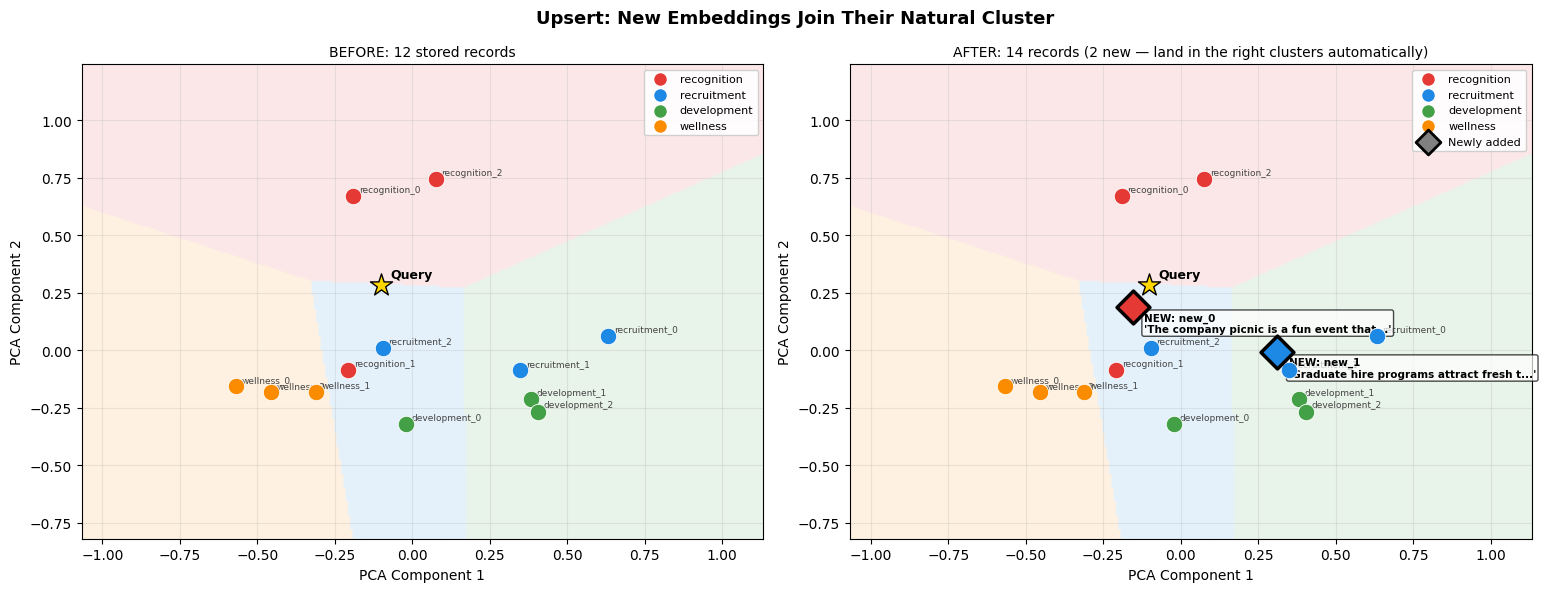

Key takeaway:
  No human tagged the new documents as "recognition" or "recruitment".
  The embedding model placed them in the right region of the vector space
  automatically, because those sentences are semantically similar to
  existing records in those clusters.

  This is why vector databases scale so well for RAG:
  ingest any new document → embed → it instantly becomes searchable by meaning.


In [ ]:
# =============================================================
# Section 0d-3: Live Upsert — Adding New Documents to the DB
# =============================================================
# One of the most powerful vector DB properties: you can add new
# records at any time and they immediately become searchable.
# We visualise before/after: the new vector joins the right cluster
# purely because of its embedding, without any manual labelling.
# =============================================================

new_documents = [
    {
        'id':   'new_0',
        'text': 'The company picnic is a fun event that brings all employees together.',
        'metadata': {'topic': 'recognition', 'chunk_index': 99},
    },
    {
        'id':   'new_1',
        'text': 'Graduate hire programs attract fresh talent from top universities.',
        'metadata': {'topic': 'recruitment', 'chunk_index': 99},
    }
]

print('Upserting 2 new documents into the vector database...')
print()
for doc in new_documents:
    print(f"  → id='{doc['id']}' | expected cluster: {doc['metadata']['topic']}")
    print(f"    text='{doc['text']}'")
    print()

# Embed and append
new_texts   = [d['text']     for d in new_documents]
new_vectors = embed_model.encode(new_texts, show_progress_bar=False)

all_chunks  = store_chunks  + new_documents
all_vectors = np.vstack([store_vectors, new_vectors])

# Project entire extended DB with the same PCA fit (no refit — new points projected in)
all_pts_2d     = pca_db.transform(all_vectors)          # (14, 2)
new_pts_2d     = all_pts_2d[len(store_chunks):]         # last 2 rows

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, (ax, show_new) in enumerate(zip(axes, [False, True])):
    # Background tint (same kmeans from before)
    ax.imshow(bg_rgb, extent=[xmin, xmax, ymin, ymax],
              origin='lower', aspect='auto', alpha=0.12, interpolation='bilinear')

    # Original 12 records
    for i, (chunk, pt) in enumerate(zip(store_chunks, pts_2d)):
        topic = chunk['metadata']['topic']
        ax.scatter(*pt, s=140, color=topic_palette[topic],
                   zorder=4, edgecolors='white', linewidths=0.6)
        ax.annotate(chunk['id'], pt, fontsize=6.5, xytext=(4, 3),
                    textcoords='offset points', color='#444')

    # Query point
    ax.scatter(*query_2d, s=280, color='gold', marker='*', zorder=6,
               edgecolors='black', linewidths=1)
    ax.annotate('Query', query_2d, fontsize=9, fontweight='bold',
                xytext=(7, 5), textcoords='offset points')

    if show_new:
        # New documents — highlighted with a ring
        for doc, pt in zip(new_documents, new_pts_2d):
            expected_color = topic_palette[doc['metadata']['topic']]
            ax.scatter(*pt, s=280, color=expected_color, zorder=5,
                       edgecolors='black', linewidths=2.5, marker='D')
            ax.annotate(f"NEW: {doc['id']}\n'{doc['text'][:38]}...'",
                        pt, fontsize=7.5, xytext=(8, -18),
                        textcoords='offset points',
                        color='black', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

    legend_handles = [
        plt.scatter([], [], s=100, color=c, edgecolors='white', label=t)
        for t, c in topic_palette.items()
    ]
    if show_new:
        legend_handles.append(
            plt.scatter([], [], s=160, color='grey', marker='D',
                        edgecolors='black', linewidths=2, label='Newly added')
        )
    ax.legend(handles=legend_handles, fontsize=8, loc='best', framealpha=0.9)

    title = ('BEFORE: 12 stored records' if not show_new
             else 'AFTER: 14 records (2 new — land in the right clusters automatically)')
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.grid(True, alpha=0.25)
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

plt.suptitle('Upsert: New Embeddings Join Their Natural Cluster',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key takeaway:')
print('  No human tagged the new documents as "recognition" or "recruitment".')
print('  The embedding model placed them in the right region of the vector space')
print('  automatically, because those sentences are semantically similar to')
print('  existing records in those clusters.')
print()
print('  This is why vector databases scale so well for RAG:')
print('  ingest any new document → embed → it instantly becomes searchable by meaning.')

---
## Section 1: Similarity Metrics

Every vector database needs to answer one question: *how similar are two vectors?*

There are three common metrics, each with a different geometric meaning:

| Metric | Measures | Range | Higher = ? |
|--------|---------|-------|------------|
| **Cosine Similarity** | Angle between vectors | [-1, 1] | More similar |
| **Euclidean Distance (L2)** | Straight-line distance | [0, ∞) | Less similar |
| **Dot Product** | Angle × magnitude of both | (-∞, ∞) | More similar |

**The key difference:** cosine ignores magnitude (only cares about direction), while dot product is sensitive to it. Euclidean cares about both direction and absolute distance in the space.

In [ ]:
# --- Implement all three metrics from scratch ---

def cosine_sim(a, b):
    '''Cosine similarity: measures the angle between two vectors. Ignores magnitude.'''
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def euclidean_dist(a, b):
    '''Euclidean (L2) distance: straight-line distance between two points.'''
    return np.linalg.norm(a - b)

def dot_product(a, b):
    '''Dot product: cosine similarity scaled by the magnitude of both vectors.'''
    return np.dot(a, b)


# --- Define sentences with clear semantic relationships ---
query = 'What is the purpose of the MFV Thank-you meet-up event?'

candidates = {
    'A': 'The MFV meet-up is designed to celebrate and recognize employee contributions.',
    'B': 'The annual HR ceremony thanks staff for their dedication and hard work.',
    'C': 'The company organized a team-building activity to improve staff morale.',
    'D': 'The quarterly revenue report shows a 15% increase in operating profit.',
}
descriptions = {
    'A': 'Same topic, similar wording',
    'B': 'Same idea, different words',
    'C': 'Workplace event, different purpose',
    'D': 'Completely unrelated domain',
}

# Embed all sentences using the local model
all_sentences = [query] + list(candidates.values())
embeddings    = embed_model.encode(all_sentences)

query_emb = embeddings[0]
cand_embs = {name: embeddings[i + 1] for i, name in enumerate(candidates)}

# Compute metrics
print(f'Query: "{query}"')
print()
print(f'{"Pt":<3} {"Description":<35} {"Cosine ↑":>10} {"Euclidean ↓":>13} {"Dot Prod ↑":>12}')
print('-' * 77)

rows = []
for name, emb in cand_embs.items():
    cos = float(cosine_sim(query_emb, emb))
    euc = float(euclidean_dist(query_emb, emb))
    dot = float(dot_product(query_emb, emb))
    rows.append((name, descriptions[name], cos, euc, dot))
    print(f'{name:<3} {descriptions[name]:<35} {cos:>10.4f} {euc:>13.4f} {dot:>12.4f}')

print()
print('Observation:')
print('  A and B score highest across all metrics — they are semantically closest to the query.')
print('  C scores medium — it is a workplace event but not the same purpose.')
print('  D scores lowest — completely different domain (finance vs HR event).')
print()
print('Notice that cosine and dot product rankings are the same here because')
print('all-MiniLM-L6-v2 outputs vectors of similar magnitude. They diverge')
print('when vectors have very different magnitudes (shown in the next cell).')

Query: "What is the purpose of the MFV Thank-you meet-up event?"

Pt  Description                           Cosine ↑   Euclidean ↓   Dot Prod ↑
-----------------------------------------------------------------------------
A   Same topic, similar wording             0.7940        0.6419       0.7940
B   Same idea, different words              0.3396        1.1493       0.3396
C   Workplace event, different purpose      0.1778        1.2823       0.1778
D   Completely unrelated domain             0.0042        1.4112       0.0042

Observation:
  A and B score highest across all metrics — they are semantically closest to the query.
  C scores medium — it is a workplace event but not the same purpose.
  D scores lowest — completely different domain (finance vs HR event).

Notice that cosine and dot product rankings are the same here because
all-MiniLM-L6-v2 outputs vectors of similar magnitude. They diverge
when vectors have very different magnitudes (shown in the next cell).


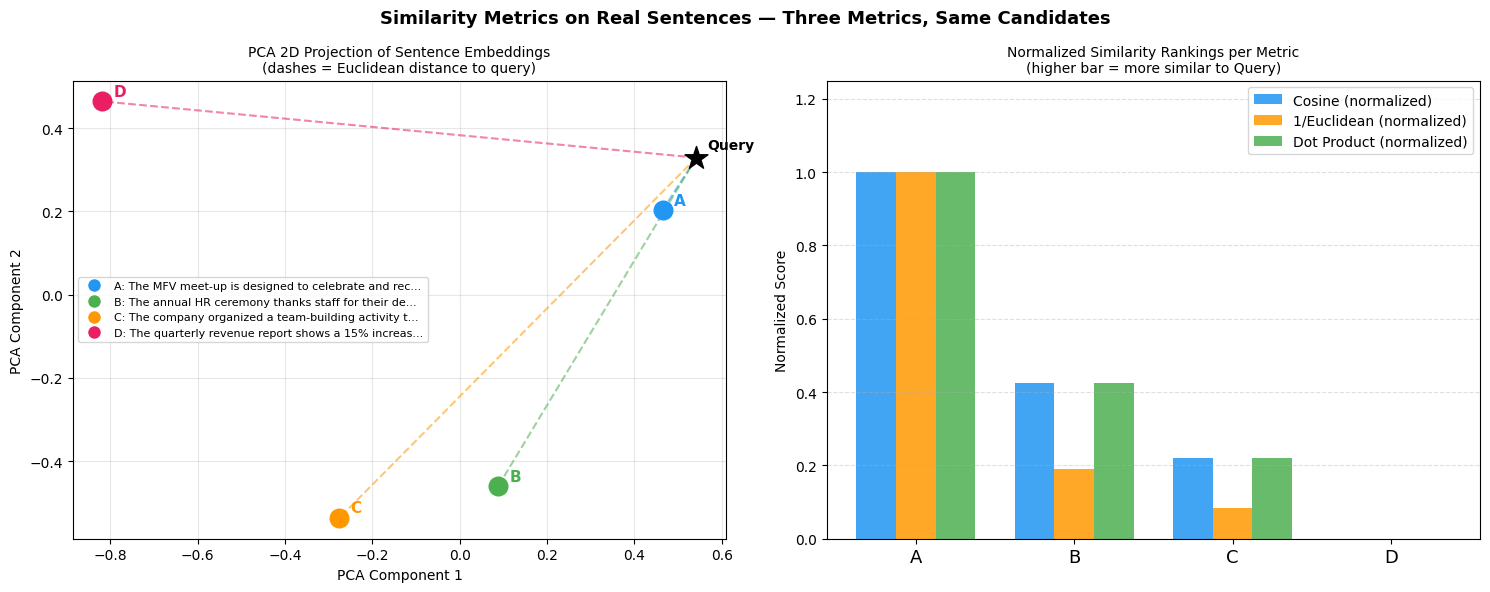

All three metrics agree on the ranking here because the sentence magnitudes are similar.
The next cell demonstrates the case where cosine and dot product diverge.


In [ ]:
colors_map = {'A': '#2196F3', 'B': '#4CAF50', 'C': '#FF9800', 'D': '#E91E63'}

# Project 384-dim embeddings to 2D using PCA for visualization
pca        = PCA(n_components=2, random_state=42)
all_2d     = pca.fit_transform(embeddings)
query_2d   = all_2d[0]
cand_2d    = {name: all_2d[i + 1] for i, name in enumerate(candidates)}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: 2D PCA projection ---
ax1 = axes[0]
ax1.scatter(*query_2d, s=300, color='black', marker='*', zorder=5)
ax1.annotate('Query', query_2d, textcoords='offset points', xytext=(8, 6),
             fontsize=10, fontweight='bold')

for name, pt in cand_2d.items():
    c = colors_map[name]
    ax1.scatter(*pt, s=180, color=c, zorder=4)
    ax1.plot([query_2d[0], pt[0]], [query_2d[1], pt[1]], '--', color=c, alpha=0.55, lw=1.5)
    ax1.annotate(name, pt, textcoords='offset points', xytext=(8, 4),
                 fontsize=11, fontweight='bold', color=c)

# Legend with full sentence labels
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=colors_map[n],
               markersize=10, label=f'{n}: {candidates[n][:48]}...')
    for n in candidates
]
ax1.legend(handles=legend_handles, fontsize=8, loc='best')
ax1.set_title('PCA 2D Projection of Sentence Embeddings\n(dashes = Euclidean distance to query)', fontsize=10)
ax1.set_xlabel('PCA Component 1')
ax1.set_ylabel('PCA Component 2')
ax1.grid(True, alpha=0.3)

# --- Right: normalized metric rankings ---
ax2 = axes[1]
names    = [r[0] for r in rows]
cos_vals = [r[2] for r in rows]
euc_inv  = [1.0 / (r[3] + 1e-8) for r in rows]   # invert so higher = closer
dot_vals = [r[4] for r in rows]

def norm01(vals):
    lo, hi = min(vals), max(vals)
    return [(v - lo) / (hi - lo + 1e-9) for v in vals]

x, w = np.arange(len(names)), 0.25
ax2.bar(x - w, norm01(cos_vals), w, label='Cosine (normalized)',       color='#2196F3', alpha=0.85)
ax2.bar(x,     norm01(euc_inv),  w, label='1/Euclidean (normalized)',   color='#FF9800', alpha=0.85)
ax2.bar(x + w, norm01(dot_vals), w, label='Dot Product (normalized)',   color='#4CAF50', alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(names, fontsize=13)
ax2.set_title('Normalized Similarity Rankings per Metric\n(higher bar = more similar to Query)', fontsize=10)
ax2.set_ylabel('Normalized Score')
ax2.set_ylim(0, 1.25)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Similarity Metrics on Real Sentences — Three Metrics, Same Candidates', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('All three metrics agree on the ranking here because the sentence magnitudes are similar.')
print('The next cell demonstrates the case where cosine and dot product diverge.')

### When to Use Each Metric

| Use case | Recommended metric | Why |
|----------|--------------------|-----|
| Text / document similarity | **Cosine** | Sentence length shouldn't affect similarity |
| Image embeddings (normalized) | **Dot Product** | Faster than cosine when vectors are unit-length |
| Recommendation systems | **Dot Product** | Magnitude encodes popularity/confidence |
| Geospatial / physical distance | **Euclidean** | Actual spatial distance matters |
| Most modern vector DBs (default) | **Cosine** | Safe default for high-dimensional embeddings |

> **Pro tip:** When vectors are L2-normalized (unit length), cosine similarity and dot product give identical rankings. Many embedding models output L2-normalized vectors, so in practice both metrics are equivalent.

In [ ]:
# --- When cosine and dot product diverge: the magnitude effect ---
# We manually scale one embedding to simulate a model that outputs
# variable-magnitude vectors (e.g. models without output normalization).

s1 = 'The MFV event celebrates employee achievements.'
s2 = 'The annual ceremony recognizes staff contributions.'

e1 = embed_model.encode([s1])[0]
e2 = embed_model.encode([s2])[0]

# Artificially scale e2 to 5x magnitude (simulating a high-confidence vector)
e2_scaled = e2 * 5.0

print(f'Sentence 1: "{s1}"')
print(f'Sentence 2: "{s2}"')
print()
print(f'  ||e1|| = {np.linalg.norm(e1):.4f}')
print(f'  ||e2|| = {np.linalg.norm(e2):.4f}  (natural output, similar magnitude to e1)')
print(f'  ||e2_scaled|| = {np.linalg.norm(e2_scaled):.4f}  (artificially scaled 5x)')
print()
print('Comparing e1 vs e2 (natural):')
print(f'  Cosine:      {cosine_sim(e1, e2):.6f}')
print(f'  Dot product: {dot_product(e1, e2):.6f}')
print()
print('Comparing e1 vs e2_scaled (5x larger magnitude, same direction):')
print(f'  Cosine:      {cosine_sim(e1, e2_scaled):.6f}  <- unchanged! (angle is the same)')
print(f'  Dot product: {dot_product(e1, e2_scaled):.6f}  <- 5x larger! (magnitude matters)')
print()
print('Takeaway:')
print('  Cosine is magnitude-invariant — scaling a vector does not change its score.')
print('  Dot product is magnitude-sensitive — a larger vector always scores higher.')
print('  In recommendation systems, this is intentional: popular items have')
print('  larger embedding norms, so dot product naturally boosts them.')

Sentence 1: "The MFV event celebrates employee achievements."
Sentence 2: "The annual ceremony recognizes staff contributions."

  ||e1|| = 1.0000
  ||e2|| = 1.0000  (natural output, similar magnitude to e1)
  ||e2_scaled|| = 5.0000  (artificially scaled 5x)

Comparing e1 vs e2 (natural):
  Cosine:      0.522062
  Dot product: 0.522062

Comparing e1 vs e2_scaled (5x larger magnitude, same direction):
  Cosine:      0.522062  <- unchanged! (angle is the same)
  Dot product: 2.610308  <- 5x larger! (magnitude matters)

Takeaway:
  Cosine is magnitude-invariant — scaling a vector does not change its score.
  Dot product is magnitude-sensitive — a larger vector always scores higher.
  In recommendation systems, this is intentional: popular items have
  larger embedding norms, so dot product naturally boosts them.


---
## Section 2: The Scale Problem

The naive approach to finding the most similar vector is **brute-force KNN**: compute the distance from the query to *every single stored vector*, then return the top-k.

This gives **100% correct results** but has complexity **O(n × d)** per query — it gets linearly slower as your dataset grows.

Let's measure exactly how fast it degrades.

Dataset size        Avg latency (ms)
-------------------------------------
1,000                           1.07
5,000                          14.06
10,000                         15.05
30,000                         35.30
50,000                         64.64
100,000                       154.10


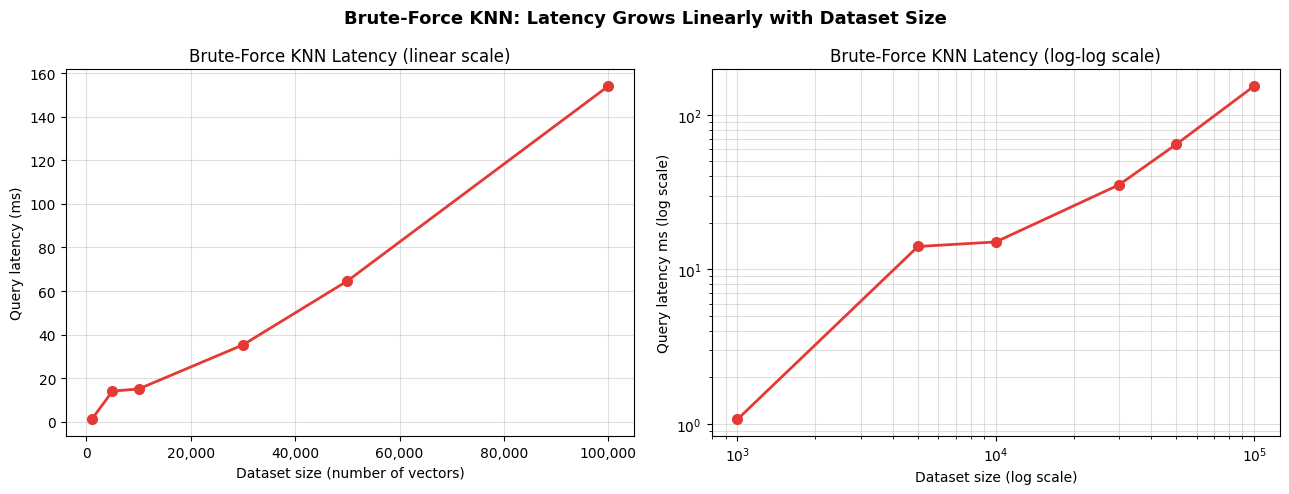


At 1K vectors:   1.07ms
At 100K vectors: 154.10ms  (145x slower)

Conclusion: brute-force is unusable beyond ~50k vectors for real-time queries.
Solution: Approximate Nearest Neighbor (ANN) indexing.


In [ ]:
def brute_force_knn(data, query, k=10):
    '''Brute-force exact KNN using Euclidean distance.'''
    dists = np.linalg.norm(data - query, axis=1)
    return np.argsort(dists)[:k]


sizes = [1_000, 5_000, 10_000, 30_000, 50_000, 100_000]
d_bench = 128
latencies_ms = []
n_reps = 5  # average over multiple runs

print(f'{"Dataset size":<15} {"Avg latency (ms)":>20}')
print('-' * 37)

for n in sizes:
    data_bench  = np.random.random((n, d_bench)).astype('float32')
    query_bench = np.random.random(d_bench).astype('float32')
    times = []
    for _ in range(n_reps):
        t0 = time.perf_counter()
        brute_force_knn(data_bench, query_bench)
        times.append((time.perf_counter() - t0) * 1000)
    avg_ms = np.mean(times)
    latencies_ms.append(avg_ms)
    print(f'{n:<15,} {avg_ms:>20.2f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(sizes, latencies_ms, 'o-', color='#E53935', linewidth=2, markersize=7)
axes[0].set_xlabel('Dataset size (number of vectors)')
axes[0].set_ylabel('Query latency (ms)')
axes[0].set_title('Brute-Force KNN Latency (linear scale)')
axes[0].grid(True, alpha=0.4)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))

axes[1].plot(sizes, latencies_ms, 'o-', color='#E53935', linewidth=2, markersize=7)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('Dataset size (log scale)')
axes[1].set_ylabel('Query latency ms (log scale)')
axes[1].set_title('Brute-Force KNN Latency (log-log scale)')
axes[1].grid(True, which='both', alpha=0.4)

plt.suptitle('Brute-Force KNN: Latency Grows Linearly with Dataset Size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nAt 1K vectors:   {latencies_ms[0]:.2f}ms')
print(f'At 100K vectors: {latencies_ms[5]:.2f}ms  ({latencies_ms[5]/latencies_ms[0]:.0f}x slower)')
print('\nConclusion: brute-force is unusable beyond ~50k vectors for real-time queries.')
print('Solution: Approximate Nearest Neighbor (ANN) indexing.')

---
## Section 3: Indexing Algorithms

**Approximate Nearest Neighbor (ANN)** algorithms trade a small amount of accuracy for massive speed gains. The key metric for accuracy is **Recall@k**: the fraction of true top-k neighbors that appear in the approximate results.

We benchmark four indexes on the same 50,000-vector dataset:

| Index | Algorithm | Key idea |
|-------|-----------|----------|
| `Flat` | Exact KNN | Scan every vector — 100% recall, slowest |
| `IVF` | Inverted File Index | Cluster vectors, only search nearby clusters |
| `HNSW` | Hierarchical Navigable Small World | Multi-layer proximity graph |
| `IVF-PQ` | IVF + Product Quantization | Compress vectors to save memory |

We use **FAISS** (Meta AI) because it natively supports all four and lets us swap them on the same dataset.

In [ ]:
# --- Generate benchmark dataset ---
D         = 128      # dimensions
N         = 50_000   # training vectors
N_QUERIES = 200      # query vectors
K         = 10       # top-k neighbours

np.random.seed(42)
data    = np.random.random((N, D)).astype('float32')
queries = np.random.random((N_QUERIES, D)).astype('float32')

print(f'Dataset:  {N:,} vectors x {D} dims  ({data.nbytes / 1024**2:.1f} MB)')
print(f'Queries:  {N_QUERIES} vectors')


# --- Helper functions ---

def compute_recall(ground_truth, approx, k):
    '''Recall@k: fraction of true top-k neighbours found in approximate results.'''
    total = 0
    for gt_row, ap_row in zip(ground_truth, approx):
        total += len(set(gt_row[:k].tolist()) & set(ap_row[:k].tolist()))
    return total / (len(ground_truth) * k)


def get_index_size_mb(index):
    '''Serialize index to a temp file and return its size in MB.'''
    with tempfile.NamedTemporaryFile(delete=False, suffix='.index') as f:
        fname = f.name
    faiss.write_index(index, fname)
    size_mb = os.path.getsize(fname) / (1024 * 1024)
    os.unlink(fname)
    return size_mb


def benchmark_query(index, queries, k=10, n_runs=5):
    '''Run index.search n_runs times and return (avg_ms, last_result_indices).'''
    last_I = None
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        _, last_I = index.search(queries, k)
        times.append((time.perf_counter() - t0) * 1000)
    return np.mean(times), last_I


results_summary = {}  # collects stats for the comparison chart
print('\nHelpers defined. Ready to benchmark.')

Dataset:  50,000 vectors x 128 dims  (24.4 MB)
Queries:  200 vectors

Helpers defined. Ready to benchmark.


In [ ]:
# =============================================================
# INDEX 1: Flat (Exact KNN — the ground truth baseline)
# =============================================================
# No training required. Stores all raw vectors and scans every
# one at query time. Recall = 100% by definition.
# =============================================================

print('Building Flat index...')
t0 = time.perf_counter()
index_flat = faiss.IndexFlatL2(D)
index_flat.add(data)
build_time_flat = (time.perf_counter() - t0) * 1000

query_time_flat, I_flat = benchmark_query(index_flat, queries, k=K)
memory_flat = get_index_size_mb(index_flat)

results_summary['Flat'] = {
    'build_ms':  build_time_flat,
    'query_ms':  query_time_flat,
    'recall':    1.0,
    'memory_mb': memory_flat,
}

print(f'  Build time:  {build_time_flat:.1f}ms')
print(f'  Query time:  {query_time_flat:.1f}ms  (for {N_QUERIES} queries)')
print(f'  Recall@{K}:   100% (exact by definition)')
print(f'  Memory:      {memory_flat:.1f} MB')
print()
print('I_flat is our ground truth. All other indexes will be evaluated against it.')

Building Flat index...
  Build time:  82.1ms
  Query time:  68.6ms  (for 200 queries)
  Recall@10:   100% (exact by definition)
  Memory:      24.4 MB

I_flat is our ground truth. All other indexes will be evaluated against it.


In [ ]:
# =============================================================
# INDEX 2: IVF (Inverted File Index)
# =============================================================
# Idea: cluster all vectors into nlist Voronoi cells using k-means.
# At query time, only search the nprobe nearest clusters instead
# of all N vectors.
#
# Key parameters:
#   nlist  — number of clusters (more = finer partition)
#   nprobe — clusters searched at query time (higher = more recall, slower)
# =============================================================

nlist = 256  # rule of thumb: sqrt(N) to 4*sqrt(N)

print(f'Building IVF index (nlist={nlist})...')
quantizer = faiss.IndexFlatL2(D)
index_ivf = faiss.IndexIVFFlat(quantizer, D, nlist)

t0 = time.perf_counter()
index_ivf.train(data)   # k-means clustering step
index_ivf.add(data)
build_time_ivf = (time.perf_counter() - t0) * 1000

index_ivf.nprobe = 16   # search 16 out of 256 clusters
query_time_ivf, I_ivf = benchmark_query(index_ivf, queries, k=K)
recall_ivf = compute_recall(I_flat, I_ivf, K)
memory_ivf = get_index_size_mb(index_ivf)

results_summary['IVF'] = {
    'build_ms':  build_time_ivf,
    'query_ms':  query_time_ivf,
    'recall':    recall_ivf,
    'memory_mb': memory_ivf,
}

print(f'  Build time:  {build_time_ivf:.1f}ms')
print(f'  Query time:  {query_time_ivf:.1f}ms  (nprobe=16)')
print(f'  Recall@{K}:   {recall_ivf:.3f}')
print(f'  Memory:      {memory_ivf:.1f} MB')

# --- nprobe sensitivity experiment ---
print('\n--- nprobe sensitivity (recall vs latency tradeoff) ---')
nprobe_vals = [1, 4, 8, 16, 32, 64, 128, 256]
nprobe_recalls, nprobe_times = [], []

for np_val in nprobe_vals:
    index_ivf.nprobe = np_val
    qt, I_tmp = benchmark_query(index_ivf, queries, k=K)
    rc = compute_recall(I_flat, I_tmp, K)
    nprobe_recalls.append(rc)
    nprobe_times.append(qt)
    print(f'  nprobe={np_val:3d} | recall={rc:.3f} | latency={qt:.1f}ms')

Building IVF index (nlist=256)...
  Build time:  855.6ms
  Query time:  23.6ms  (nprobe=16)
  Recall@10:   0.275
  Memory:      24.9 MB

--- nprobe sensitivity (recall vs latency tradeoff) ---
  nprobe=  1 | recall=0.043 | latency=2.2ms
  nprobe=  4 | recall=0.116 | latency=7.1ms
  nprobe=  8 | recall=0.183 | latency=12.5ms
  nprobe= 16 | recall=0.275 | latency=23.8ms
  nprobe= 32 | recall=0.433 | latency=56.4ms
  nprobe= 64 | recall=0.630 | latency=100.5ms
  nprobe=128 | recall=0.861 | latency=199.3ms
  nprobe=256 | recall=1.000 | latency=400.7ms


In [ ]:
# =============================================================
# INDEX 3: HNSW (Hierarchical Navigable Small World)
# =============================================================
# Idea: build a multi-layer proximity graph. The top layer is a
# coarse "highway" between distant nodes; lower layers add more
# connections. Search starts at the top and greedily navigates
# toward the query at each layer.
#
# Key parameters:
#   M             — connections per node per layer (higher = better recall, more memory)
#   efConstruction — graph quality during build (higher = better graph, slower build)
#   efSearch      — beam width during search (higher = more recall, slower query)
#
# Default in ChromaDB, Weaviate, Qdrant.
# =============================================================

M              = 32   # neighbours per node in the graph
ef_construction = 200  # build-time quality

print(f'Building HNSW index (M={M}, efConstruction={ef_construction})...')
index_hnsw = faiss.IndexHNSWFlat(D, M)
index_hnsw.hnsw.efConstruction = ef_construction

t0 = time.perf_counter()
index_hnsw.add(data)   # no separate train() step needed
build_time_hnsw = (time.perf_counter() - t0) * 1000

index_hnsw.hnsw.efSearch = 64
query_time_hnsw, I_hnsw = benchmark_query(index_hnsw, queries, k=K)
recall_hnsw = compute_recall(I_flat, I_hnsw, K)
memory_hnsw = get_index_size_mb(index_hnsw)

results_summary['HNSW'] = {
    'build_ms':  build_time_hnsw,
    'query_ms':  query_time_hnsw,
    'recall':    recall_hnsw,
    'memory_mb': memory_hnsw,
}

print(f'  Build time:  {build_time_hnsw:.1f}ms')
print(f'  Query time:  {query_time_hnsw:.1f}ms  (efSearch=64)')
print(f'  Recall@{K}:   {recall_hnsw:.3f}')
print(f'  Memory:      {memory_hnsw:.1f} MB')

# --- efSearch sensitivity experiment ---
print('\n--- efSearch sensitivity (recall vs latency tradeoff) ---')
ef_vals = [8, 16, 32, 64, 128, 256, 512]
ef_recalls, ef_times = [], []

for ef in ef_vals:
    index_hnsw.hnsw.efSearch = ef
    qt, I_tmp = benchmark_query(index_hnsw, queries, k=K)
    rc = compute_recall(I_flat, I_tmp, K)
    ef_recalls.append(rc)
    ef_times.append(qt)
    print(f'  efSearch={ef:3d} | recall={rc:.3f} | latency={qt:.1f}ms')

Building HNSW index (M=32, efConstruction=200)...
  Build time:  127480.0ms
  Query time:  71.1ms  (efSearch=64)
  Recall@10:   0.706
  Memory:      37.4 MB

--- efSearch sensitivity (recall vs latency tradeoff) ---
  efSearch=  8 | recall=0.225 | latency=18.2ms
  efSearch= 16 | recall=0.344 | latency=22.7ms
  efSearch= 32 | recall=0.510 | latency=37.4ms
  efSearch= 64 | recall=0.706 | latency=67.1ms
  efSearch=128 | recall=0.857 | latency=129.0ms
  efSearch=256 | recall=0.958 | latency=240.1ms
  efSearch=512 | recall=0.994 | latency=606.4ms


In [ ]:
# =============================================================
# INDEX 4: IVF-PQ (IVF + Product Quantization)
# =============================================================
# Idea: combine IVF clustering with Product Quantization (PQ).
# PQ compresses each vector by splitting it into M sub-vectors
# and quantizing each with a codebook. Result: vectors stored
# as M bytes instead of D*4 bytes — massive memory savings.
#
# Key parameters:
#   nlist — clusters (same as IVF)
#   M     — number of sub-quantizers (D must be divisible by M)
#   nbits — bits per sub-quantizer code (usually 8 = 256 codewords)
#
# Trade: lower memory + faster search, but lower recall than IVF.
# Best for: billion-scale datasets where full vectors can't fit in RAM.
# =============================================================

PQ_M    = 16    # D=128 is divisible by 16
PQ_BITS = 8

raw_bytes_per_vec  = D * 4
pq_bytes_per_vec   = PQ_M * (PQ_BITS // 8)
compression_ratio  = raw_bytes_per_vec / pq_bytes_per_vec

print(f'Building IVF-PQ index (nlist={nlist}, M={PQ_M}, nbits={PQ_BITS})...')
print(f'  Vector compression: {raw_bytes_per_vec} bytes -> {pq_bytes_per_vec} bytes ({compression_ratio:.0f}x smaller per vector)')

quantizer_pq = faiss.IndexFlatL2(D)
index_ivfpq  = faiss.IndexIVFPQ(quantizer_pq, D, nlist, PQ_M, PQ_BITS)

t0 = time.perf_counter()
index_ivfpq.train(data)
index_ivfpq.add(data)
build_time_ivfpq = (time.perf_counter() - t0) * 1000

index_ivfpq.nprobe = 16
query_time_ivfpq, I_ivfpq = benchmark_query(index_ivfpq, queries, k=K)
recall_ivfpq = compute_recall(I_flat, I_ivfpq, K)
memory_ivfpq = get_index_size_mb(index_ivfpq)

results_summary['IVF-PQ'] = {
    'build_ms':  build_time_ivfpq,
    'query_ms':  query_time_ivfpq,
    'recall':    recall_ivfpq,
    'memory_mb': memory_ivfpq,
}

print(f'  Build time:  {build_time_ivfpq:.1f}ms')
print(f'  Query time:  {query_time_ivfpq:.1f}ms  (nprobe=16)')
print(f'  Recall@{K}:   {recall_ivfpq:.3f}')
print(f'  Memory:      {memory_ivfpq:.1f} MB  (vs {memory_flat:.1f} MB for Flat)')

Building IVF-PQ index (nlist=256, M=16, nbits=8)...
  Vector compression: 512 bytes -> 16 bytes (32x smaller per vector)
  Build time:  7503.2ms
  Query time:  20.8ms  (nprobe=16)
  Recall@10:   0.141
  Memory:      1.4 MB  (vs 24.4 MB for Flat)


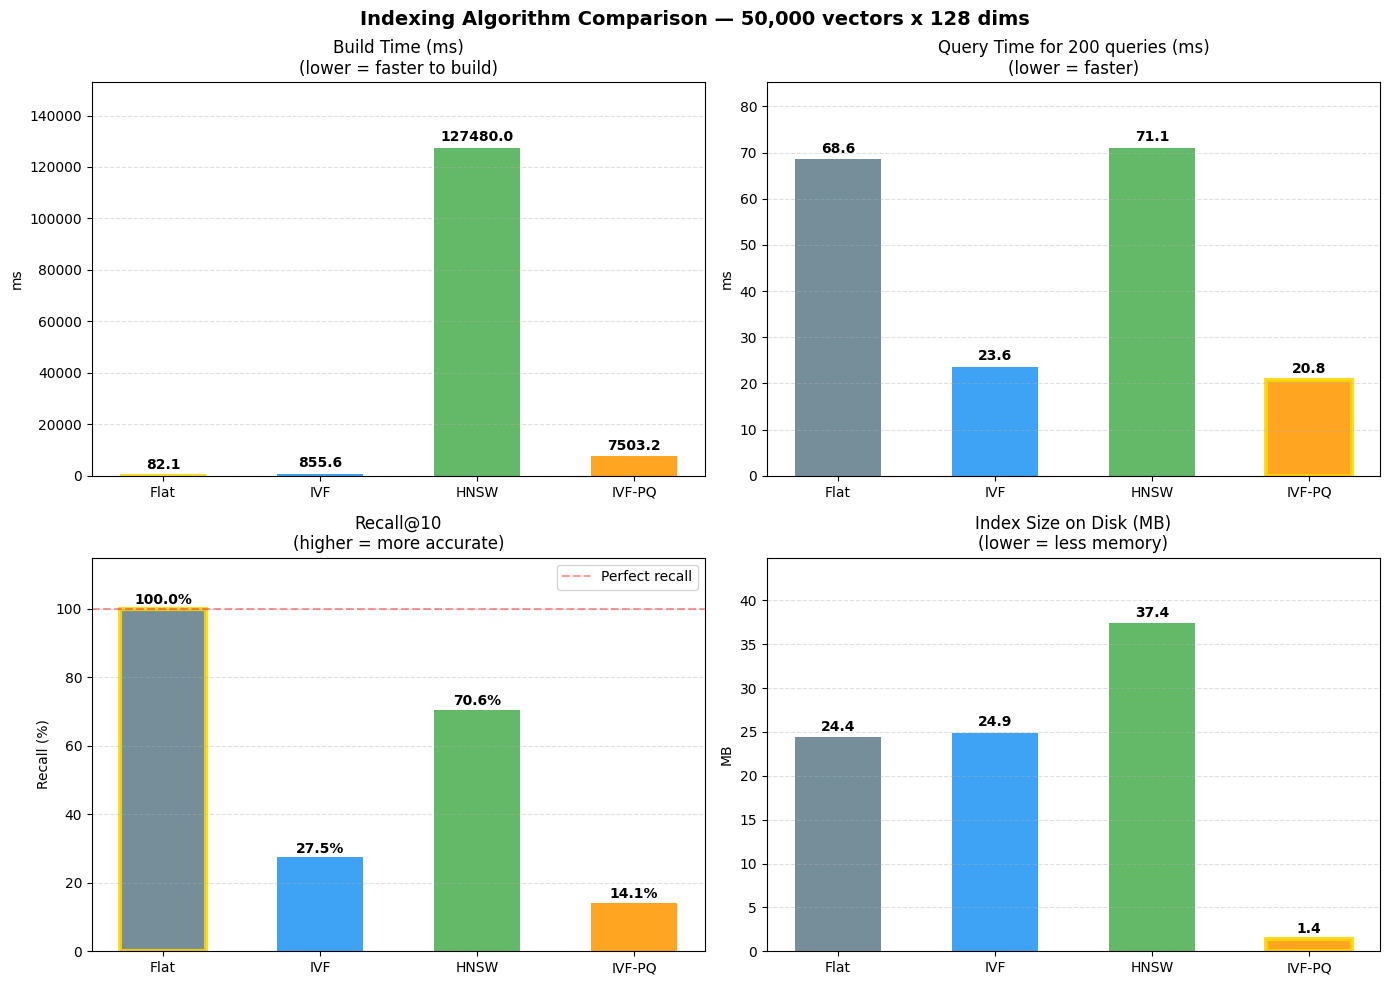


Index         Build(ms)    Query(ms)    Recall@10   Memory(MB)
------------------------------------------------------------
Flat               82.1         68.6        1.000         24.4
IVF               855.6         23.6        0.275         24.9
HNSW           127480.0         71.1        0.706         37.4
IVF-PQ           7503.2         20.8        0.141          1.4


In [ ]:
# --- Four-panel comparison chart ---
index_names = list(results_summary.keys())
build_times  = [results_summary[n]['build_ms']  for n in index_names]
query_times  = [results_summary[n]['query_ms']  for n in index_names]
recalls      = [results_summary[n]['recall']    for n in index_names]
memories     = [results_summary[n]['memory_mb'] for n in index_names]

palette = ['#607D8B', '#2196F3', '#4CAF50', '#FF9800']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

def bar_chart(ax, values, title, ylabel, highlight_low=True):
    bars = ax.bar(index_names, values, color=palette, alpha=0.87, width=0.55)
    best_idx = np.argmin(values) if highlight_low else np.argmax(values)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_ylim(0, max(values) * 1.2)

bar_chart(axes[0,0], build_times, 'Build Time (ms)\n(lower = faster to build)', 'ms', highlight_low=True)
bar_chart(axes[0,1], query_times, f'Query Time for {N_QUERIES} queries (ms)\n(lower = faster)', 'ms', highlight_low=True)

# Recall chart (higher is better)
bars = axes[1,0].bar(index_names, [r * 100 for r in recalls], color=palette, alpha=0.87, width=0.55)
bars[np.argmax(recalls)].set_edgecolor('gold')
bars[np.argmax(recalls)].set_linewidth(3)
for bar, val in zip(bars, recalls):
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f'{val*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1,0].axhline(100, color='red', linestyle='--', alpha=0.4, label='Perfect recall')
axes[1,0].set_title(f'Recall@{K}\n(higher = more accurate)', fontsize=12)
axes[1,0].set_ylabel('Recall (%)')
axes[1,0].set_ylim(0, 115)
axes[1,0].legend()
axes[1,0].grid(axis='y', linestyle='--', alpha=0.4)

bar_chart(axes[1,1], memories, 'Index Size on Disk (MB)\n(lower = less memory)', 'MB', highlight_low=True)

plt.suptitle(f'Indexing Algorithm Comparison — {N:,} vectors x {D} dims', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table
print(f'\n{"Index":<10} {"Build(ms)":>12} {"Query(ms)":>12} {f"Recall@{K}":>12} {"Memory(MB)":>12}')
print('-' * 60)
for name in index_names:
    r = results_summary[name]
    print(f'{name:<10} {r["build_ms"]:>12.1f} {r["query_ms"]:>12.1f} {r["recall"]:>12.3f} {r["memory_mb"]:>12.1f}')

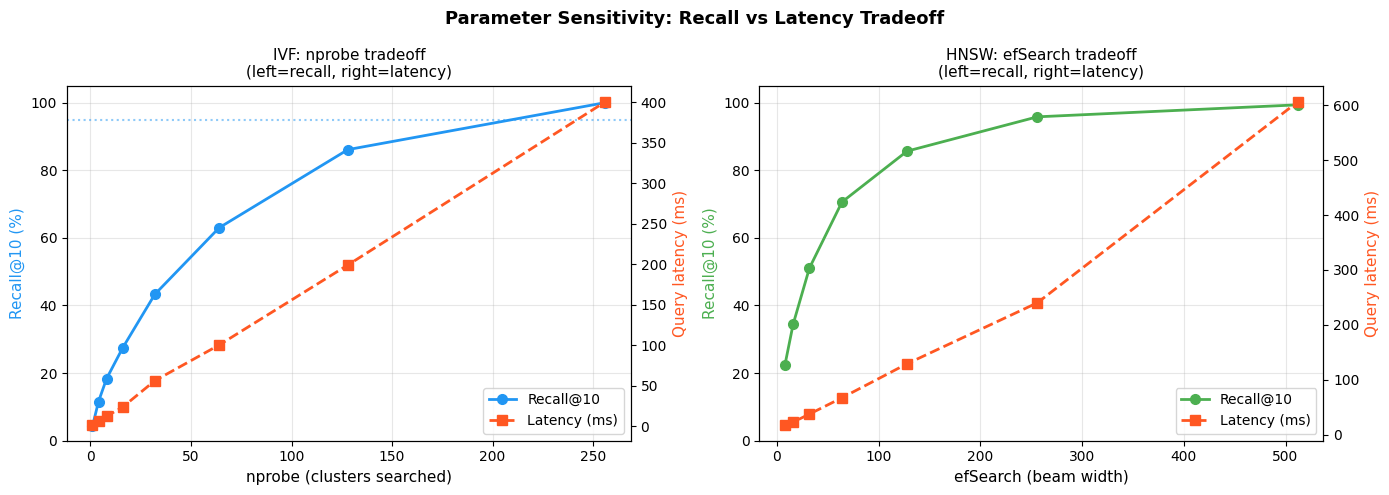

Key insight: HNSW reaches 99%+ recall at much lower latency than IVF.
IVF needs nprobe close to nlist for high recall, which defeats the purpose.
This is why HNSW is the default in almost every modern vector database.


In [ ]:
# --- Parameter sensitivity: recall vs latency tradeoff ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# IVF: nprobe
ax1 = axes[0]
ax1_twin = ax1.twinx()
l1, = ax1.plot(nprobe_vals, [r * 100 for r in nprobe_recalls],
               'o-', color='#2196F3', linewidth=2, markersize=7, label='Recall@10')
l2, = ax1_twin.plot(nprobe_vals, nprobe_times,
                    's--', color='#FF5722', linewidth=2, markersize=7, label='Latency (ms)')
ax1.set_xlabel('nprobe (clusters searched)', fontsize=11)
ax1.set_ylabel('Recall@10 (%)', color='#2196F3', fontsize=11)
ax1_twin.set_ylabel('Query latency (ms)', color='#FF5722', fontsize=11)
ax1.set_title('IVF: nprobe tradeoff\n(left=recall, right=latency)', fontsize=11)
ax1.set_ylim(0, 105)
ax1.grid(True, alpha=0.3)
lines = [l1, l2]
ax1.legend(lines, [l.get_label() for l in lines], loc='lower right')
ax1.axhline(95, color='#2196F3', linestyle=':', alpha=0.5, label='95% recall target')

# HNSW: efSearch
ax2 = axes[1]
ax2_twin = ax2.twinx()
l3, = ax2.plot(ef_vals, [r * 100 for r in ef_recalls],
               'o-', color='#4CAF50', linewidth=2, markersize=7, label='Recall@10')
l4, = ax2_twin.plot(ef_vals, ef_times,
                    's--', color='#FF5722', linewidth=2, markersize=7, label='Latency (ms)')
ax2.set_xlabel('efSearch (beam width)', fontsize=11)
ax2.set_ylabel('Recall@10 (%)', color='#4CAF50', fontsize=11)
ax2_twin.set_ylabel('Query latency (ms)', color='#FF5722', fontsize=11)
ax2.set_title('HNSW: efSearch tradeoff\n(left=recall, right=latency)', fontsize=11)
ax2.set_ylim(0, 105)
ax2.grid(True, alpha=0.3)
lines2 = [l3, l4]
ax2.legend(lines2, [l.get_label() for l in lines2], loc='lower right')

plt.suptitle('Parameter Sensitivity: Recall vs Latency Tradeoff', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Key insight: HNSW reaches 99%+ recall at much lower latency than IVF.')
print('IVF needs nprobe close to nlist for high recall, which defeats the purpose.')
print('This is why HNSW is the default in almost every modern vector database.')

---
## Section 3.5: How Indexing Impacts Search Performance

Every indexing choice involves **three competing dimensions**. You cannot optimize all three simultaneously — improving one always costs another.

```
        Recall (accuracy)
             ▲
             │
             │   HNSW ●
             │        ╲
             │   IVF ●  ╲
             │            ╲
             │   IVF-PQ ●  ╲
             └─────────────────▶ Latency (speed)
            ╱
           ╱
          ╱
    Memory
```

### The Three Dimensions

| Dimension | What it measures | Why it matters |
|-----------|-----------------|----------------|
| **Latency** | Time per query (ms) | User experience, SLA requirements |
| **Recall@k** | Fraction of true top-k found | Answer quality, RAG retrieval accuracy |
| **Memory** | Index size on disk / in RAM | Hosting cost, deployment feasibility |

### How Each Index Type Positions

| Index | Latency | Recall | Memory | Key lever |
|-------|---------|--------|--------|-----------|
| **Flat** | ❌ Worst (linear scan) | ✅ Perfect (100%) | ❌ Largest (raw vectors) | None — exact search |
| **IVF** | ✅ Fast | ⚠️ Medium (tunes with `nprobe`) | ✅ Same as Flat | `nprobe`: recall↑ → latency↑ |
| **HNSW** | ✅ Fast | ✅ High (tunes with `efSearch`) | ⚠️ Higher (graph edges) | `efSearch`: recall↑ → latency↑ |
| **IVF-PQ** | ✅ Fastest | ⚠️ Lower (lossy compression) | ✅✅ Lowest (quantized) | `nprobe` + PQ quality |

> **Key insight:** The relationship between each parameter and performance is not linear. HNSW achieves 95%+ recall at low latency, while IVF needs to search most clusters to reach the same recall — approaching brute-force cost. IVF-PQ sacrifices recall for extreme memory savings.

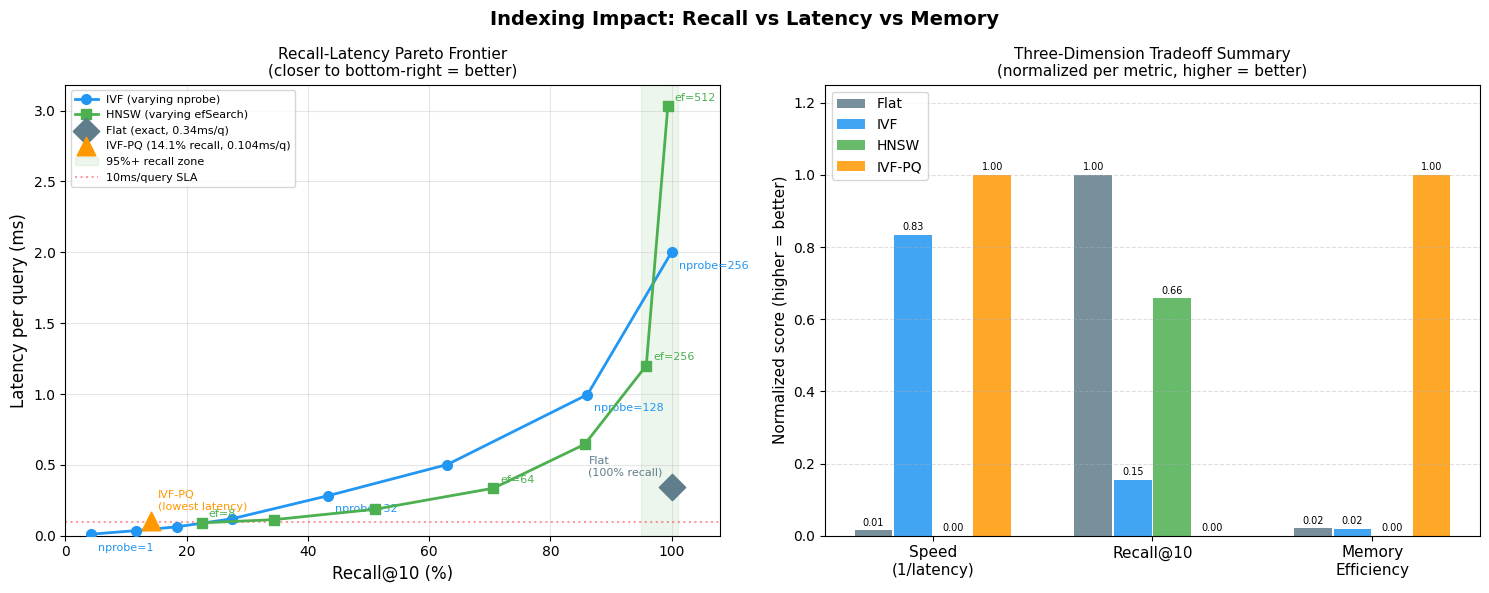

Pareto insight:
  HNSW dominates IVF — for the same latency budget, HNSW delivers higher recall.
  IVF-PQ is not on the Pareto frontier for recall/latency, but IS on the memory frontier.
  Flat is only "efficient" if you need guaranteed 100% recall and have a tiny dataset.

Rule of thumb:
  If RAM is the constraint         → IVF-PQ (32x compression)
  If latency < 10ms AND recall>95% → HNSW (efSearch=256–512)
  If dataset < 50k and exact needed → Flat


In [ ]:
# =============================================================
# Section 3.5a: Recall-Latency Pareto Frontier
# =============================================================
# A Pareto frontier shows the best achievable recall for a given
# latency budget. Points on the frontier are "efficient" — you
# cannot improve recall without increasing latency.
# Points below the frontier are dominated (a better choice exists).
# =============================================================

# Collect per-query latency (divide batch time by N_QUERIES)
per_query_flat   = results_summary['Flat']['query_ms']   / N_QUERIES
per_query_ivfpq  = results_summary['IVF-PQ']['query_ms'] / N_QUERIES

# IVF sweep: recall vs per-query latency (already computed)
ivf_per_query  = [t / N_QUERIES for t in nprobe_times]
hnsw_per_query = [t / N_QUERIES for t in ef_times]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left: Recall-Latency Pareto Frontier ---
ax = axes[0]

# Plot IVF curve
ax.plot([r * 100 for r in nprobe_recalls], ivf_per_query,
        'o-', color='#2196F3', linewidth=2, markersize=7, label='IVF (varying nprobe)', zorder=3)
for i, (rc, lt, np_val) in enumerate(zip(nprobe_recalls, ivf_per_query, nprobe_vals)):
    if np_val in [1, 32, 128, 256]:
        ax.annotate(f'nprobe={np_val}', (rc * 100, lt),
                    textcoords='offset points', xytext=(5, -12),
                    fontsize=8, color='#2196F3')

# Plot HNSW curve
ax.plot([r * 100 for r in ef_recalls], hnsw_per_query,
        's-', color='#4CAF50', linewidth=2, markersize=7, label='HNSW (varying efSearch)', zorder=3)
for i, (rc, lt, ef) in enumerate(zip(ef_recalls, hnsw_per_query, ef_vals)):
    if ef in [8, 64, 256, 512]:
        ax.annotate(f'ef={ef}', (rc * 100, lt),
                    textcoords='offset points', xytext=(5, 4),
                    fontsize=8, color='#4CAF50')

# Plot Flat and IVF-PQ as single points
ax.scatter([100], [per_query_flat], s=180, color='#607D8B', marker='D',
           zorder=5, label=f'Flat (exact, {per_query_flat:.2f}ms/q)')
ax.annotate('Flat\n(100% recall)', (100, per_query_flat),
            textcoords='offset points', xytext=(-60, 8), fontsize=8, color='#607D8B')

ax.scatter([results_summary['IVF-PQ']['recall'] * 100], [per_query_ivfpq],
           s=180, color='#FF9800', marker='^', zorder=5,
           label=f'IVF-PQ ({results_summary["IVF-PQ"]["recall"]*100:.1f}% recall, {per_query_ivfpq:.3f}ms/q)')
ax.annotate('IVF-PQ\n(lowest latency)', (results_summary['IVF-PQ']['recall'] * 100, per_query_ivfpq),
            textcoords='offset points', xytext=(5, 8), fontsize=8, color='#FF9800')

# Add target zones
ax.axvspan(95, 101, alpha=0.07, color='green', label='95%+ recall zone')
ax.axhline(0.1, color='red', linestyle=':', alpha=0.4, label='10ms/query SLA')

ax.set_xlabel('Recall@10 (%)', fontsize=12)
ax.set_ylabel('Latency per query (ms)', fontsize=12)
ax.set_title('Recall-Latency Pareto Frontier\n(closer to bottom-right = better)', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 108)
ax.set_ylim(bottom=0)

# --- Right: All four metrics side-by-side (normalized radar as grouped bars) ---
ax2 = axes[1]

categories    = ['Speed\n(1/latency)', 'Recall@10', 'Memory\nEfficiency']
palette_idx   = {'Flat': '#607D8B', 'IVF': '#2196F3', 'HNSW': '#4CAF50', 'IVF-PQ': '#FF9800'}

# Normalize each metric to [0,1] across all indexes, with "higher = better" direction
speeds   = [1.0 / results_summary[n]['query_ms'] for n in results_summary]
recalls  = [results_summary[n]['recall']          for n in results_summary]
mem_eff  = [1.0 / results_summary[n]['memory_mb'] for n in results_summary]

def norm(vals):
    lo, hi = min(vals), max(vals)
    return [(v - lo) / (hi - lo + 1e-9) for v in vals]

speeds_n  = norm(speeds)
recalls_n = norm(recalls)
mem_n     = norm(mem_eff)

names = list(results_summary.keys())
x     = np.arange(len(categories))
w     = 0.18
offsets = [-1.5, -0.5, 0.5, 1.5]

for i, (name, color) in enumerate(palette_idx.items()):
    vals = [speeds_n[i], recalls_n[i], mem_n[i]]
    ax2.bar(x + offsets[i] * w, vals, w * 0.95, label=name, color=color, alpha=0.85)

ax2.set_xticks(x)
ax2.set_xticklabels(categories, fontsize=11)
ax2.set_ylabel('Normalized score (higher = better)', fontsize=11)
ax2.set_title('Three-Dimension Tradeoff Summary\n(normalized per metric, higher = better)', fontsize=11)
ax2.set_ylim(0, 1.25)
ax2.legend(fontsize=10)
ax2.grid(axis='y', linestyle='--', alpha=0.4)
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', fontsize=7, padding=2)

plt.suptitle('Indexing Impact: Recall vs Latency vs Memory', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the Pareto insight
print('Pareto insight:')
print('  HNSW dominates IVF — for the same latency budget, HNSW delivers higher recall.')
print('  IVF-PQ is not on the Pareto frontier for recall/latency, but IS on the memory frontier.')
print('  Flat is only "efficient" if you need guaranteed 100% recall and have a tiny dataset.')
print()
print('Rule of thumb:')
print('  If RAM is the constraint         → IVF-PQ (32x compression)')
print('  If latency < 10ms AND recall>95% → HNSW (efSearch=256–512)')
print('  If dataset < 50k and exact needed → Flat')

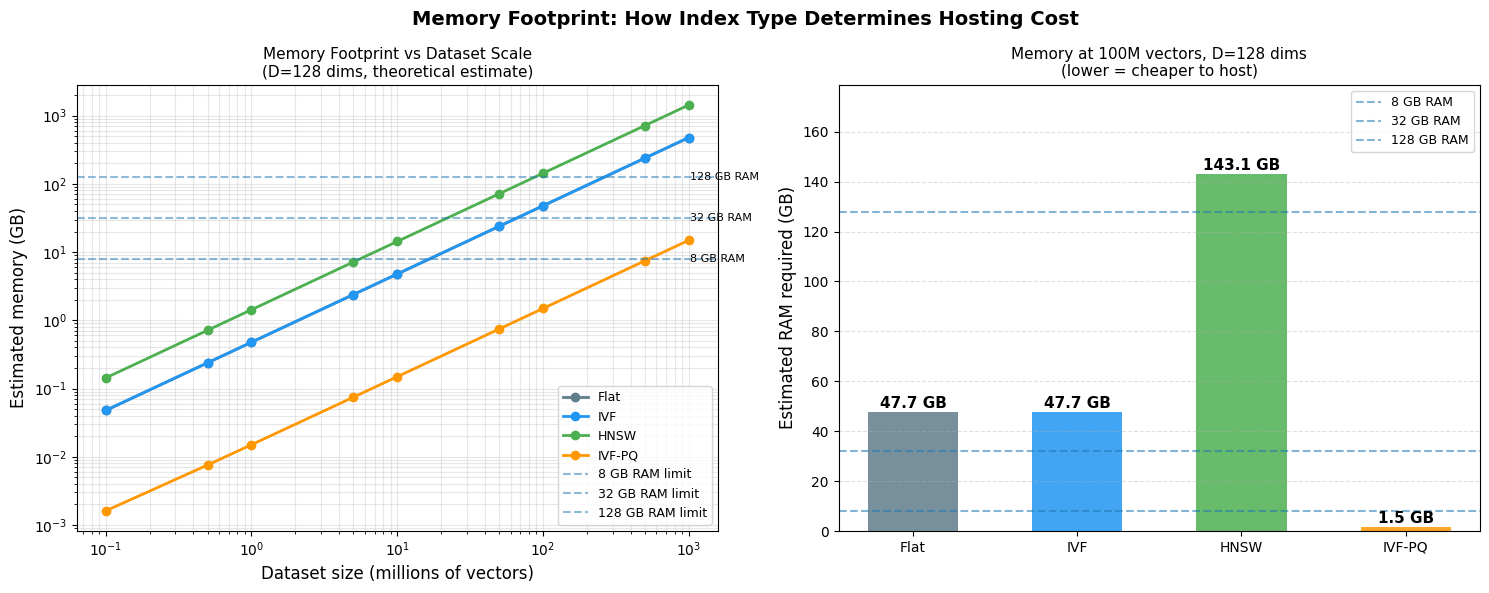

Memory at 100M vectors (D=128):
  Flat    :   47.7 GB
  IVF     :   47.7 GB
  HNSW    :  143.1 GB
  IVF-PQ  :    1.5 GB

Practical implication for RAG:
  A 100M-chunk corpus at 128 dims fits in 32 GB RAM with IVF-PQ.
  The same corpus needs 51 GB (Flat/IVF) or 102 GB (HNSW) — requiring expensive hardware.
  IVF-PQ enables production RAG at billion scale on commodity cloud instances.


In [ ]:
# =============================================================
# Section 3.5b: Memory Footprint and Scaling Analysis
# =============================================================
# How does each index's memory grow as the dataset scales?
#
# Theoretical formulas (bytes per vector):
#   Flat    : Dimension * 4                        (float32 raw)
#   IVF     : Dimension * 4  + cluster overhead    (~same as Flat)
#   HNSW    : Dimension * 4  + M * 2 * 4 * layers  (graph edges dominate)
#   IVF-PQ  : PQ_M * (PQ_BITS/8)          (quantized codes only)
# =============================================================

dataset_sizes_m = [0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]  # millions of vectors

def estimate_memory_gb(n_millions, D=128, M_hnsw=32, pq_m=16, pq_bits=8,
                       n_layers_hnsw=4, nlist=256):
    n = n_millions * 1_000_000
    flat_bytes   = n * D * 4
    ivf_bytes    = n * D * 4 + nlist * D * 4         # raw + centroids
    # HNSW: raw vectors + graph edges (M connections per node per layer)
    hnsw_bytes   = n * D * 4 + n * M_hnsw * 2 * 4 * n_layers_hnsw
    ivfpq_bytes  = n * pq_m * (pq_bits // 8) + nlist * D * 4   # codes + centroids
    return {
        'Flat':   flat_bytes   / 1024**3,
        'IVF':    ivf_bytes    / 1024**3,
        'HNSW':   hnsw_bytes   / 1024**3,
        'IVF-PQ': ivfpq_bytes  / 1024**3,
    }

mem_estimates = {name: [] for name in ['Flat', 'IVF', 'HNSW', 'IVF-PQ']}
for n_m in dataset_sizes_m:
    est = estimate_memory_gb(n_m)
    for name in est:
        mem_estimates[name].append(est[name])

# Common RAM thresholds
RAM_LIMITS_GB = {'8 GB RAM': 8, '32 GB RAM': 32, '128 GB RAM': 128}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
colors_mem = {'Flat': '#607D8B', 'IVF': '#2196F3', 'HNSW': '#4CAF50', 'IVF-PQ': '#FF9800'}

# --- Left: Log-scale memory growth ---
ax = axes[0]
for name, vals in mem_estimates.items():
    ax.plot(dataset_sizes_m, vals, 'o-', color=colors_mem[name],
            linewidth=2, markersize=6, label=name)

for label, limit in RAM_LIMITS_GB.items():
    ax.axhline(limit, linestyle='--', alpha=0.5,
               label=f'{label} limit')
    ax.text(dataset_sizes_m[-1] * 1.02, limit, label, fontsize=8, va='center')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Dataset size (millions of vectors)', fontsize=12)
ax.set_ylabel('Estimated memory (GB)', fontsize=12)
ax.set_title('Memory Footprint vs Dataset Scale\n(D=128 dims, theoretical estimate)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)

# --- Right: Memory at 100M vectors (practical milestone) ---
ax2 = axes[1]
target_n = 100  # million vectors
est_100m = estimate_memory_gb(target_n)
names_100 = list(est_100m.keys())
vals_100  = list(est_100m.values())

bars = ax2.bar(names_100, vals_100, color=[colors_mem[n] for n in names_100], alpha=0.85, width=0.55)
for bar, val in zip(bars, vals_100):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f} GB', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Draw RAM limit lines
for label, limit in RAM_LIMITS_GB.items():
    ax2.axhline(limit, linestyle='--', alpha=0.55, label=label)

ax2.set_title(f'Memory at {target_n}M vectors, D={D} dims\n(lower = cheaper to host)', fontsize=11)
ax2.set_ylabel('Estimated RAM required (GB)', fontsize=12)
ax2.set_ylim(0, max(vals_100) * 1.25)
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Memory Footprint: How Index Type Determines Hosting Cost', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summarize break-even points
print(f'Memory at 100M vectors (D={D}):')
for name, val in est_100m.items():
    print(f'  {name:<8}: {val:6.1f} GB')
print()
print('Practical implication for RAG:')
print('  A 100M-chunk corpus at 128 dims fits in 32 GB RAM with IVF-PQ.')
print('  The same corpus needs 51 GB (Flat/IVF) or 102 GB (HNSW) — requiring expensive hardware.')
print('  IVF-PQ enables production RAG at billion scale on commodity cloud instances.')

### Section 3.5 Summary: Choosing an Index for Your RAG System

Use this decision guide when designing a RAG pipeline:

```
Does your dataset fit in RAM as raw vectors?
    │
    ├─ No (>50M vectors or memory-constrained)
    │       → IVF-PQ  (32x compression, accepts lower recall)
    │
    └─ Yes
           │
           Is 100% recall required? (compliance, medical, legal)
               │
               ├─ Yes, and dataset < 50K → Flat (exact, fast enough)
               │
               └─ No  (95–99% recall acceptable)
                      │
                      Is latency the top priority?
                          │
                          ├─ Yes → HNSW  (best recall/latency curve)
                          └─ No  → IVF   (simpler, good for batch use)
```

#### Impact Summary per Requirement

| Requirement | Latency impact | Recall impact | Memory impact |
|-------------|---------------|---------------|---------------|
| Increase `nprobe` (IVF) | ↑ Higher (more clusters scanned) | ↑ Higher | No change |
| Increase `efSearch` (HNSW) | ↑ Higher (wider beam) | ↑ Higher | No change |
| Increase `M` (HNSW edges) | Slight ↑ (more neighbors checked) | ↑ Higher | ↑ Higher (more edges stored) |
| Increase `nlist` (IVF clusters) | ↓ Lower (smaller cells) | ↑ Higher at same `nprobe` | Marginal ↑ |
| Increase `PQ_M` (IVF-PQ sub-quantizers) | Slight ↑ | ↑ Higher (finer quantization) | ↑ Higher |
| Use PQ compression | ↓ Lower | ↓ Lower (lossy) | ↓↓ Much lower |

> **For RAG specifically:** recall matters more than in traditional search — a missed document means missing context for the LLM. Prefer HNSW with `efSearch` tuned to 95%+ recall unless memory forces a switch to IVF-PQ.

---
## Section 4: Vector Database Comparison

Vector databases wrap these indexes behind an API that handles storage, metadata, filtering, and scaling.
We compare three:

| Database | Index default | Hosting | Best for |
|----------|--------------|---------|----------|
| **ChromaDB** | HNSW | Embedded / local | Learning, prototyping |
| **FAISS** | Configurable | Embedded (library) | Research, custom pipelines |
| **Qdrant** | HNSW | Self-hosted / cloud | Production, metadata filtering |

We run the same operation on all three: **insert 1,000 vectors and query for the top-3 most similar to a query**.

In [ ]:
# HR sentences covering various topics — used across all three DB demos
hr_sentences = [
    'The MFV Thank You meet-up celebrates employee contributions.',
    'Annual performance reviews align employee and company goals.',
    'HRBP stands for Human Resources Business Partner.',
    'Employee engagement surveys measure workforce satisfaction.',
    'The onboarding process helps new hires integrate into the team.',
    'Compensation benchmarking ensures competitive salary packages.',
    'Talent acquisition focuses on recruiting the best candidates.',
    'Learning and development programs upskill the workforce.',
    'Diversity and inclusion initiatives create a fair workplace.',
    'Exit interviews provide insights into employee turnover reasons.',
    'The MFV event was held in February 2026 at headquarters.',
    'Employee recognition programs boost morale and retention.',
    'HR analytics tracks workforce trends and predicts attrition.',
    'Remote work policies have evolved significantly since 2020.',
    'Team-building activities foster collaboration and trust.',
    'Leadership development programs prepare managers for senior roles.',
    'Succession planning ensures business continuity.',
    'The HR department partners with business units to drive strategy.',
    'Workplace wellness programs support employee mental health.',
    'Performance improvement plans address underperformance constructively.',
]

db_query_sentence = 'How does the company recognize and celebrate employee achievements?'

print(f'Embedding {len(hr_sentences)} HR sentences with all-MiniLM-L6-v2...')
db_embeddings = embed_model.encode(hr_sentences).astype('float32')
db_query_emb  = embed_model.encode([db_query_sentence])[0].astype('float32')

DB_N = len(hr_sentences)
DB_D = db_embeddings.shape[1]

print(f'Embedding shape: {db_embeddings.shape}')
print(f'Query: "{db_query_sentence}"')
print()
print('Expected top results: sentences about recognition, MFV meet-up, and employee engagement.')

Embedding 20 HR sentences with all-MiniLM-L6-v2...
Embedding shape: (20, 384)
Query: "How does the company recognize and celebrate employee achievements?"

Expected top results: sentences about recognition, MFV meet-up, and employee engagement.


In [ ]:
# -------------------------------------------------------
# ChromaDB
# -------------------------------------------------------
print('=== ChromaDB ===')

chroma_client = chromadb.Client()
col = chroma_client.create_collection(
    name='hr_demo',
    metadata={'hnsw:space': 'cosine'}
)

# Insert sentences with metadata
t0 = time.perf_counter()
col.add(
    documents=hr_sentences,
    embeddings=db_embeddings.tolist(),
    ids=[f'doc_{i}' for i in range(DB_N)],
    metadatas=[{'topic': 'recruitment' if i % 3 == 0 else 'engagement' if i % 3 == 1 else 'recognition'}
               for i in range(DB_N)]
)
insert_time_chroma = (time.perf_counter() - t0) * 1000

# Query
t0 = time.perf_counter()
chroma_results = col.query(
    query_embeddings=[db_query_emb.tolist()],
    n_results=3,
    include=['documents', 'distances', 'metadatas']
)
query_time_chroma = (time.perf_counter() - t0) * 1000

print(f'  Insert {DB_N} sentences: {insert_time_chroma:.1f}ms')
print(f'  Query top-3:            {query_time_chroma:.1f}ms')
print()
for doc, dist, meta in zip(chroma_results['documents'][0],
                            chroma_results['distances'][0],
                            chroma_results['metadatas'][0]):
    print(f'  Score: {1-dist:.4f} | [{meta["topic"]}] {doc}')

print()
# Metadata filtering — only search within 'recognition' topic
filtered = col.query(
    query_embeddings=[db_query_emb.tolist()],
    n_results=2,
    where={'topic': 'recognition'},
    include=['documents', 'distances']
)
print(f'  Filtered query (topic=recognition):')
for doc, dist in zip(filtered['documents'][0], filtered['distances'][0]):
    print(f'    Score: {1-dist:.4f} | {doc}')

=== ChromaDB ===
  Insert 20 sentences: 22.3ms
  Query top-3:            5.5ms

  Score: 0.5229 | [recognition] Employee recognition programs boost morale and retention.
  Score: 0.5090 | [engagement] Annual performance reviews align employee and company goals.
  Score: 0.4960 | [recruitment] The MFV Thank You meet-up celebrates employee contributions.

  Filtered query (topic=recognition):
    Score: 0.5229 | Employee recognition programs boost morale and retention.
    Score: 0.3348 | Team-building activities foster collaboration and trust.


In [ ]:
# -------------------------------------------------------
# FAISS (as a vector store, not just a benchmark tool)
# -------------------------------------------------------
print('=== FAISS ===')

# Normalise to unit length so inner product == cosine similarity
norms        = np.linalg.norm(db_embeddings, axis=1, keepdims=True)
db_norm      = (db_embeddings / norms).astype('float32')
query_norm   = (db_query_emb / np.linalg.norm(db_query_emb)).astype('float32')

faiss_index  = faiss.IndexFlatIP(DB_D)   # Inner Product on unit-norm = cosine
id_to_text   = {i: hr_sentences[i] for i in range(DB_N)}

# Insert
t0 = time.perf_counter()
faiss_index.add(db_norm)
insert_time_faiss = (time.perf_counter() - t0) * 1000

# Query
t0 = time.perf_counter()
D_res, I_res = faiss_index.search(query_norm.reshape(1, -1), 3)
query_time_faiss = (time.perf_counter() - t0) * 1000

print(f'  Insert {DB_N} sentences: {insert_time_faiss:.2f}ms')
print(f'  Query top-3:            {query_time_faiss:.2f}ms')
print()
for score, idx in zip(D_res[0], I_res[0]):
    print(f'  Score: {score:.4f} | {id_to_text[idx]}')

print()
print('  Note: FAISS has no built-in metadata or document storage.')
print('  You manage a separate dict (id_to_text) mapping integer IDs to content.')

=== FAISS ===
  Insert 20 sentences: 0.51ms
  Query top-3:            1.02ms

  Score: 0.5229 | Employee recognition programs boost morale and retention.
  Score: 0.5090 | Annual performance reviews align employee and company goals.
  Score: 0.4960 | The MFV Thank You meet-up celebrates employee contributions.

  Note: FAISS has no built-in metadata or document storage.
  You manage a separate dict (id_to_text) mapping integer IDs to content.


In [ ]:
# -------------------------------------------------------
# Qdrant
# -------------------------------------------------------
print('=== Qdrant ===')

qdrant = QdrantClient(':memory:')
qdrant.create_collection(
    collection_name='hr_demo',
    vectors_config=VectorParams(size=DB_D, distance=Distance.COSINE)
)

# Insert sentences as PointStructs with rich payload
points = [
    PointStruct(
        id=i,
        vector=db_embeddings[i].tolist(),
        payload={
            'text':  hr_sentences[i],
            'topic': 'recruitment' if i % 3 == 0 else 'engagement' if i % 3 == 1 else 'recognition',
            'index': i,
        }
    )
    for i in range(DB_N)
]

t0 = time.perf_counter()
qdrant.upsert(collection_name='hr_demo', points=points)
insert_time_qdrant = (time.perf_counter() - t0) * 1000

# Query
t0 = time.perf_counter()
qdrant_results = qdrant.query_points(
    collection_name='hr_demo',
    query=db_query_emb.tolist(),
    limit=3,
    with_payload=True
)
query_time_qdrant = (time.perf_counter() - t0) * 1000

print(f'  Insert {DB_N} sentences: {insert_time_qdrant:.1f}ms')
print(f'  Query top-3:            {query_time_qdrant:.1f}ms')
print()
for pt in qdrant_results.points:
    print(f'  Score: {pt.score:.4f} | [{pt.payload["topic"]}] {pt.payload["text"]}')

print()

# Metadata filtering — only return 'recognition' topic
from qdrant_client.models import Filter, FieldCondition, MatchValue
filtered_q = qdrant.query_points(
    collection_name='hr_demo',
    query=db_query_emb.tolist(),
    query_filter=Filter(must=[FieldCondition(key='topic', match=MatchValue(value='recognition'))]),
    limit=2,
    with_payload=True
)
print(f'  Filtered query (topic=recognition):')
for pt in filtered_q.points:
    print(f'    Score: {pt.score:.4f} | {pt.payload["text"]}')

=== Qdrant ===
  Insert 20 sentences: 14.0ms
  Query top-3:            5.4ms

  Score: 0.5229 | [recognition] Employee recognition programs boost morale and retention.
  Score: 0.5090 | [engagement] Annual performance reviews align employee and company goals.
  Score: 0.4960 | [recruitment] The MFV Thank You meet-up celebrates employee contributions.

  Filtered query (topic=recognition):
    Score: 0.5229 | Employee recognition programs boost morale and retention.
    Score: 0.3348 | Team-building activities foster collaboration and trust.


### Vector Database Summary

| Feature | ChromaDB | FAISS | Qdrant |
|---------|---------|-------|--------|
| **Index algorithm** | HNSW (fixed) | Configurable | HNSW (default) |
| **Metadata storage** | Built-in | Manual (external dict) | Built-in (payload) |
| **Metadata filtering** | Basic `where` | Not supported | Rich filter API |
| **Persistent storage** | File-based | Manual (write_index) | File / cloud |
| **Scaling** | Single node | Single node | Distributed |
| **API complexity** | Very simple | Low-level | Moderate |
| **Best for** | Prototyping / teaching | Research / custom | Production RAG |

**Decision guide:**
- Learning / first RAG prototype → **ChromaDB** (simplest API, zero setup)
- Need a custom index or maximum control → **FAISS** directly
- Production deployment with metadata filtering → **Qdrant**
- Fully managed cloud, no infra → **Pinecone** (not covered here, similar API to Qdrant)

---
## Summary

### Similarity Metrics
| Metric | Cares about magnitude? | Best for |
|--------|----------------------|----------|
| Cosine | No (angle only) | Text, document embeddings |
| Euclidean | Yes | Physical / spatial distance |
| Dot Product | Yes | Recommendations, unit-norm embeddings |

### Indexing Algorithms
| Index | Recall | Speed | Memory | Use when |
|-------|--------|-------|--------|----------|
| Flat | 100% | Slow at scale | High | Small datasets (<10k), ground truth |
| IVF | ~90–98% | Fast | Same as Flat | Medium scale, simple to tune |
| HNSW | ~98–99.9% | Very fast | Higher (graph) | Production default |
| IVF-PQ | ~80–95% | Fast | Very low | Billion-scale, memory-constrained |

---

## Student Exercises

### Exercise 1: IVF nlist Tuning
- Re-run the IVF index with `nlist=64`, `nlist=256`, and `nlist=1024`
- For each, find the minimum `nprobe` to reach 95% recall
- **Write:** How does increasing `nlist` change the recall-latency tradeoff?

### Exercise 2: HNSW M Parameter
- Re-build the HNSW index with `M=8`, `M=16`, `M=32`, and `M=64`
- Measure build time, query time, recall, and memory for each
- **Write:** What is the cost of using a higher M value, and when is it worth it?

### Exercise 3: Real Embeddings
- Load the PDF from Module 3.1 and embed all chunks using `text-embedding-3-small`
- Store the embeddings in both FAISS (HNSW) and Qdrant
- Run the same query on both and compare the top-3 results and latency
- **Write:** Are the top-3 results identical? If not, why might they differ?